## Practical Lab 1: Streaming Data for Predictive Maintenance with Linear Regression-Based Alerts

In this lab, the Data Stream Visualization Workshop has been extended. Robot's past readings are used to learn its current trend, then check new readings for unusual increases.
The robot has eight axes, or moving joints. Each axis has its own current reading. A sustained increase in current could be a reason to check the robot before a breakdown. It could also come from a change in workload, so an alert needs investigation.
The steps followed in this lab are:
1. Read the historical data from the Neon database.
2. Train one linear regression model for each axis.
3. Study the prediction errors and choose alert limits.
4. Create synthetic test readings, including some unusual patterns.
5. Check which patterns trigger Alerts and Errors, and plot the results.

#### 1.Setup
DATABASE_URL holds my Neon connection string. Training always comes from Neon.

The last section streams 240 synthetic readings into pm_lab_scaled_stream and queries them back for a short demonstration. PM_CLOUD_DEMO=0 skips only this write demonstration

PM_REPLAY_SPEED=20 uses the simulator's existing interval argument. Synthetic timestamps are regularly spaced, so the pause is the training median interval divided by 20. Use 1 for the original cadence. Database and chart work add processing time.

In [1]:

import os, json, hashlib, math, time
from datetime import datetime, timezone
from pathlib import Path
from uuid import uuid4
from dataclasses import dataclass
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image, Markdown, clear_output
from dotenv import load_dotenv
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from src.data_collection.data_collection_agent import (fetch_all, get_connection, insert_test_reading, fetch_test_since)
from src.data_collection.streaming_simulator import StreamingSimulator, init_stream_table
from src.data_collection.streaming_simulator import AXIS_COLUMNS as CSV_AXIS_COLUMNS
from src.web_ui import live_status


AXIS_COLUMNS = live_status.AXIS_COLUMNS
AXES = AXIS_COLUMNS  # Short alias for loops over the same eight columns.
RAW_AXES = CSV_AXIS_COLUMNS
COLORS = {"line": "#155e75", "data": "#648492", "Alert": "#c27803", "Error": "#be354a"}
plt.rcParams.update({"figure.facecolor":"#fcfcfa", "axes.facecolor":"#fcfcfa",
                    "axes.spines.top":False, "axes.spines.right":False,
                    "axes.grid":True, "grid.alpha":.18, "font.size":10})
root = Path.cwd()
assert (root/'data/RMBR4-2_export_test.csv').exists(), 'Open from the project folder.'
load_dotenv(root/'.env')
source = "cloud"
cloud_demo = os.environ.get('PM_CLOUD_DEMO','1') == '1'
replay_speed = float(os.environ.get('PM_REPLAY_SPEED','20'))
assert np.isfinite(replay_speed) and replay_speed > 0
out = root/'results'; plots = out/'plots'; plots.mkdir(parents=True,exist_ok=True)
pd.set_option('display.max_columns',20)
pd.set_option('display.precision',5)

def save_table(frame, root, name):
    frame.to_csv(root/'results'/name,index=False)

print('Training source: Neon | Timed synthetic database replay:', cloud_demo)

Training source: Neon | Timed synthetic database replay: True


#### 2.Load Robot data from Neon Db 

fetch_all() queries the robot_readings table. We then select id <= 39672 which is the snapshot boundary and check that these rows match the robot_data CSV. This is to confirm that training is on the intended data.

AXES is an alias of the existing live_status.AXIS_COLUMNS list, containing axis_1 to axis_8. Using this list to select the current readings and repeat the same steps for each axis. The file also has columns for axes 9–14, but they are empty. Zero current is kept because it can mean that the robot is idle.
The readings are kept in time order and divided them into three parts:

| Part | Code name | Rows | What it is used for |
|---|---|---:|---|
| Training: first 60% | `fit` | 23,803 | Fit the regression models and scaling values |
| Threshold tuning: next 20% | `cal` | 7,934 | Choose the alert limits and time window |
| Real testing: last 20% | `holdout` | 7,935 | Check the rules on later, unused readings |

The threshold-tuning part is also called the calibration set. We will keep the real test set separate so its results do not influence the model or the limits. We will also create a separate synthetic test set later.

In [2]:

def validate(frame):
    frame = frame.copy()
    frame["reading_time"] = pd.to_datetime(frame.reading_time, utc=True)
    if frame.empty or frame.reading_time.isna().any():
        raise ValueError("Missing timestamps or empty data.")
    if frame.reading_time.duplicated().any():
        raise ValueError("Duplicate training timestamps: resolve source duplicates first.")
    if not np.isfinite(frame[AXES].to_numpy(float)).all():
        raise ValueError("Training has missing/non-finite currents; do not interpolate across gaps.")
    if (frame[AXES] < 0).any().any() or not frame.trait.eq("current").all():
        raise ValueError("Expected nonnegative current readings.")
    return frame.sort_values("reading_time").reset_index(drop=True)


def split_data(frame):
    n = len(frame)
    return tuple(part.reset_index(drop=True) for part in
                 (frame.iloc[:int(.6*n)], frame.iloc[int(.6*n):int(.8*n)], frame.iloc[int(.8*n):]))

In [25]:

raw = pd.read_csv(root/'data/RMBR4-2_export_test.csv')
csv_frame = StreamingSimulator(root/'data/RMBR4-2_export_test.csv', interval=0).bulk_load()
CANONICAL_MAX_ID = 39672  # Original workshop snapshot boundary.
queried = fetch_all()
data = validate(queried.loc[queried.id <= CANONICAL_MAX_ID, ['trait', *AXES, 'reading_time']])
csv_frame = validate(csv_frame[['trait', *AXES, 'reading_time']])
pd.testing.assert_frame_equal(data, csv_frame, check_dtype=False, rtol=1e-10, atol=1e-10)
fit, cal, holdout = split_data(data)
display(pd.DataFrame([{'split':name, 'rows':len(frame), 'first_UTC':frame.reading_time.min(),
    'last_UTC':frame.reading_time.max(), 'idle_fraction':frame[AXES].eq(0).all(axis=1).mean()}
    for name,frame in [('fit',fit),('calibration',cal),('holdout',holdout)]]))
display(data.head())
print('Historical Neon rows verified against the original CSV:', len(data))

,split,rows,first_UTC,last_UTC,idle_fraction
0,fit,23803,2022-10-17 12:18:23.660000+00:00,2022-10-18 01:52:08.870000+00:00,0.60618
1,calibration,7934,2022-10-18 01:52:10.757000+00:00,2022-10-18 06:18:17.080000+00:00,0.84963
2,holdout,7935,2022-10-18 06:18:18.955000+00:00,2022-10-18 10:44:58.628000+00:00,0.54405


,trait,axis_1,axis_2,axis_3,axis_4,axis_5,axis_6,axis_7,axis_8,reading_time
0,current,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2022-10-17 12:18:23.660000+00:00
1,current,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2022-10-17 12:18:25.472000+00:00
2,current,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2022-10-17 12:18:27.348000+00:00
3,current,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2022-10-17 12:18:29.222000+00:00
4,current,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2022-10-17 12:18:31.117000+00:00


Historical Neon rows verified against the original CSV: 39672


#### 3.Train a linear regression model for each axis
Linear regression fits a straight line through the data. Here, we use time to predict current:

$$\text{predicted current} = \text{intercept} + \text{slope} \times \text{elapsed seconds}$$

- Time is the input. Counting seconds from the first training reading.
- Current is the value we want to predict.
- Slope shows how much the predicted current changes per second.
- Intercept is the predicted current at the start of training.


We fit a separate line for each axis because the joints draw different amounts of current. This is called univariate regression because each model has one input: time. fit_models() fits the eight models, and the next cell displays their slopes, intercepts and plots.

The scatter points show actual readings; the line shows predicted current. A line will not follow every movement of the robot. We use MAE and RMSE to measure prediction error in amps; smaller is better. R² describes how well the line explains the readings. A negative test R² means the line performs worse than using the test set's average as a comparison.

A rising line does not prove that a joint is wearing out. The robot may simply be doing more work.

In [4]:


def time_x(frame, origin):
    return (frame.reading_time - origin).dt.total_seconds().to_numpy().reshape(-1, 1)


def fit_models(fit):
    origin = fit.reading_time.iloc[0]
    x = time_x(fit, origin)
    models, rows = {}, []
    for axis in AXES:
        model = LinearRegression().fit(x, fit[axis])
        models[axis] = model
        rows.append({"axis": axis, "slope_A_per_s": model.coef_[0],
                     "slope_A_per_hour": model.coef_[0]*3600,
                     "intercept_A": model.intercept_,
                     "fit_R2": model.score(x, fit[axis]), "origin_UTC": origin.isoformat()})
    return models, origin, pd.DataFrame(rows)


def predict(frame, models, origin):
    x = time_x(frame, origin)
    return pd.DataFrame({a: models[a].predict(x) for a in AXES}, index=frame.index)


def regression_metrics(frame, predictions, split):
    return pd.DataFrame([dict(axis=a, split=split,
        MAE_A=mean_absolute_error(frame[a], predictions[a]),
        RMSE_A=math.sqrt(mean_squared_error(frame[a], predictions[a])),
        R2=r2_score(frame[a], predictions[a])) for a in AXES])


def residual_diagnostics(residuals, fit_residuals, split):
    rows = []
    for a in AXES:
        r = residuals[a]
        scale = fit_residuals[a].std(ddof=0)
        z = (r-fit_residuals[a].mean())/scale if scale else r*0
        rows.append(dict(axis=a, split=split, mean_A=r.mean(), std_A=r.std(),
            q95_A=r.quantile(.95), q99_A=r.quantile(.99), q995_A=r.quantile(.995),
            skew=r.skew(), lag1_autocorrelation=r.autocorr(),
            upper_z3_count=int((z>3).sum()), lower_z_minus3_count=int((z < -3).sum()),
            proportion_abs_z_le_1=float((z.abs()<=1).mean()),
            proportion_abs_z_le_2=float((z.abs()<=2).mean()),
            proportion_abs_z_le_3=float((z.abs()<=3).mean())))
    return pd.DataFrame(rows)


def plot_regression(frame,fit,models,origin,out):
    pred=predict(frame,models,origin)
    hours=time_x(frame,origin).ravel()/3600
    fig,axs=plt.subplots(4,2,figsize=(14,14),constrained_layout=True)
    for ax,a in zip(axs.flat,AXES):
        ax.scatter(hours,frame[a],s=2,alpha=.18,color=COLORS["data"],rasterized=True)
        ax.plot(hours,pred[a],color=COLORS["line"],lw=2,label="OLS / extrapolation")
        ax.axvline((fit.reading_time.iloc[-1]-origin).total_seconds()/3600,color="#555",ls=":",label="Fit ends")
        ax.set(title=a.replace("axis_","Axis "),xlabel="Hours since first training reading",ylabel="Current (A)")
    axs.flat[0].legend(fontsize=8)
    fig.suptitle("Eight time-only regressions • fitting and later observations",fontsize=17)
    fig.savefig(out,dpi=130);plt.close(fig)

,axis,slope_A_per_s,slope_A_per_hour,intercept_A,fit_R2,origin_UTC
0,axis_1,8.81317e-06,0.03173,0.58595,0.00286,2022-10-17T12:18:23.660000+00:00
1,axis_2,4.15115e-05,0.14944,2.92390,0.00672,2022-10-17T12:18:23.660000+00:00
2,axis_3,2.73713e-05,0.09854,2.31250,0.00519,2022-10-17T12:18:23.660000+00:00
3,axis_4,8.03008e-06,0.02891,0.48223,0.00464,2022-10-17T12:18:23.660000+00:00
4,axis_5,1.05987e-05,0.03816,0.78881,0.00456,2022-10-17T12:18:23.660000+00:00
5,axis_6,6.85998e-06,0.02470,0.48407,0.00259,2022-10-17T12:18:23.660000+00:00
6,axis_7,1.11029e-05,0.03997,0.68027,0.00472,2022-10-17T12:18:23.660000+00:00
7,axis_8,1.28747e-06,0.00463,0.07958,0.00166,2022-10-17T12:18:23.660000+00:00


,axis,split,MAE_A,RMSE_A,R2
0,axis_1,fit,1.18578,2.28978,0.00286
1,axis_2,fit,5.11269,7.02854,0.00672
2,axis_3,fit,3.81364,5.27696,0.00519
3,axis_4,fit,0.93218,1.63676,0.00464
4,axis_5,fit,1.41530,2.18044,0.00456
5,axis_6,fit,0.92631,1.87431,0.00259
6,axis_7,fit,1.42736,2.24596,0.00472
7,axis_8,fit,0.15268,0.43984,0.00166
8,axis_1,calibration,1.21497,1.70149,-0.26969
9,axis_2,calibration,5.51953,6.22611,-0.61206


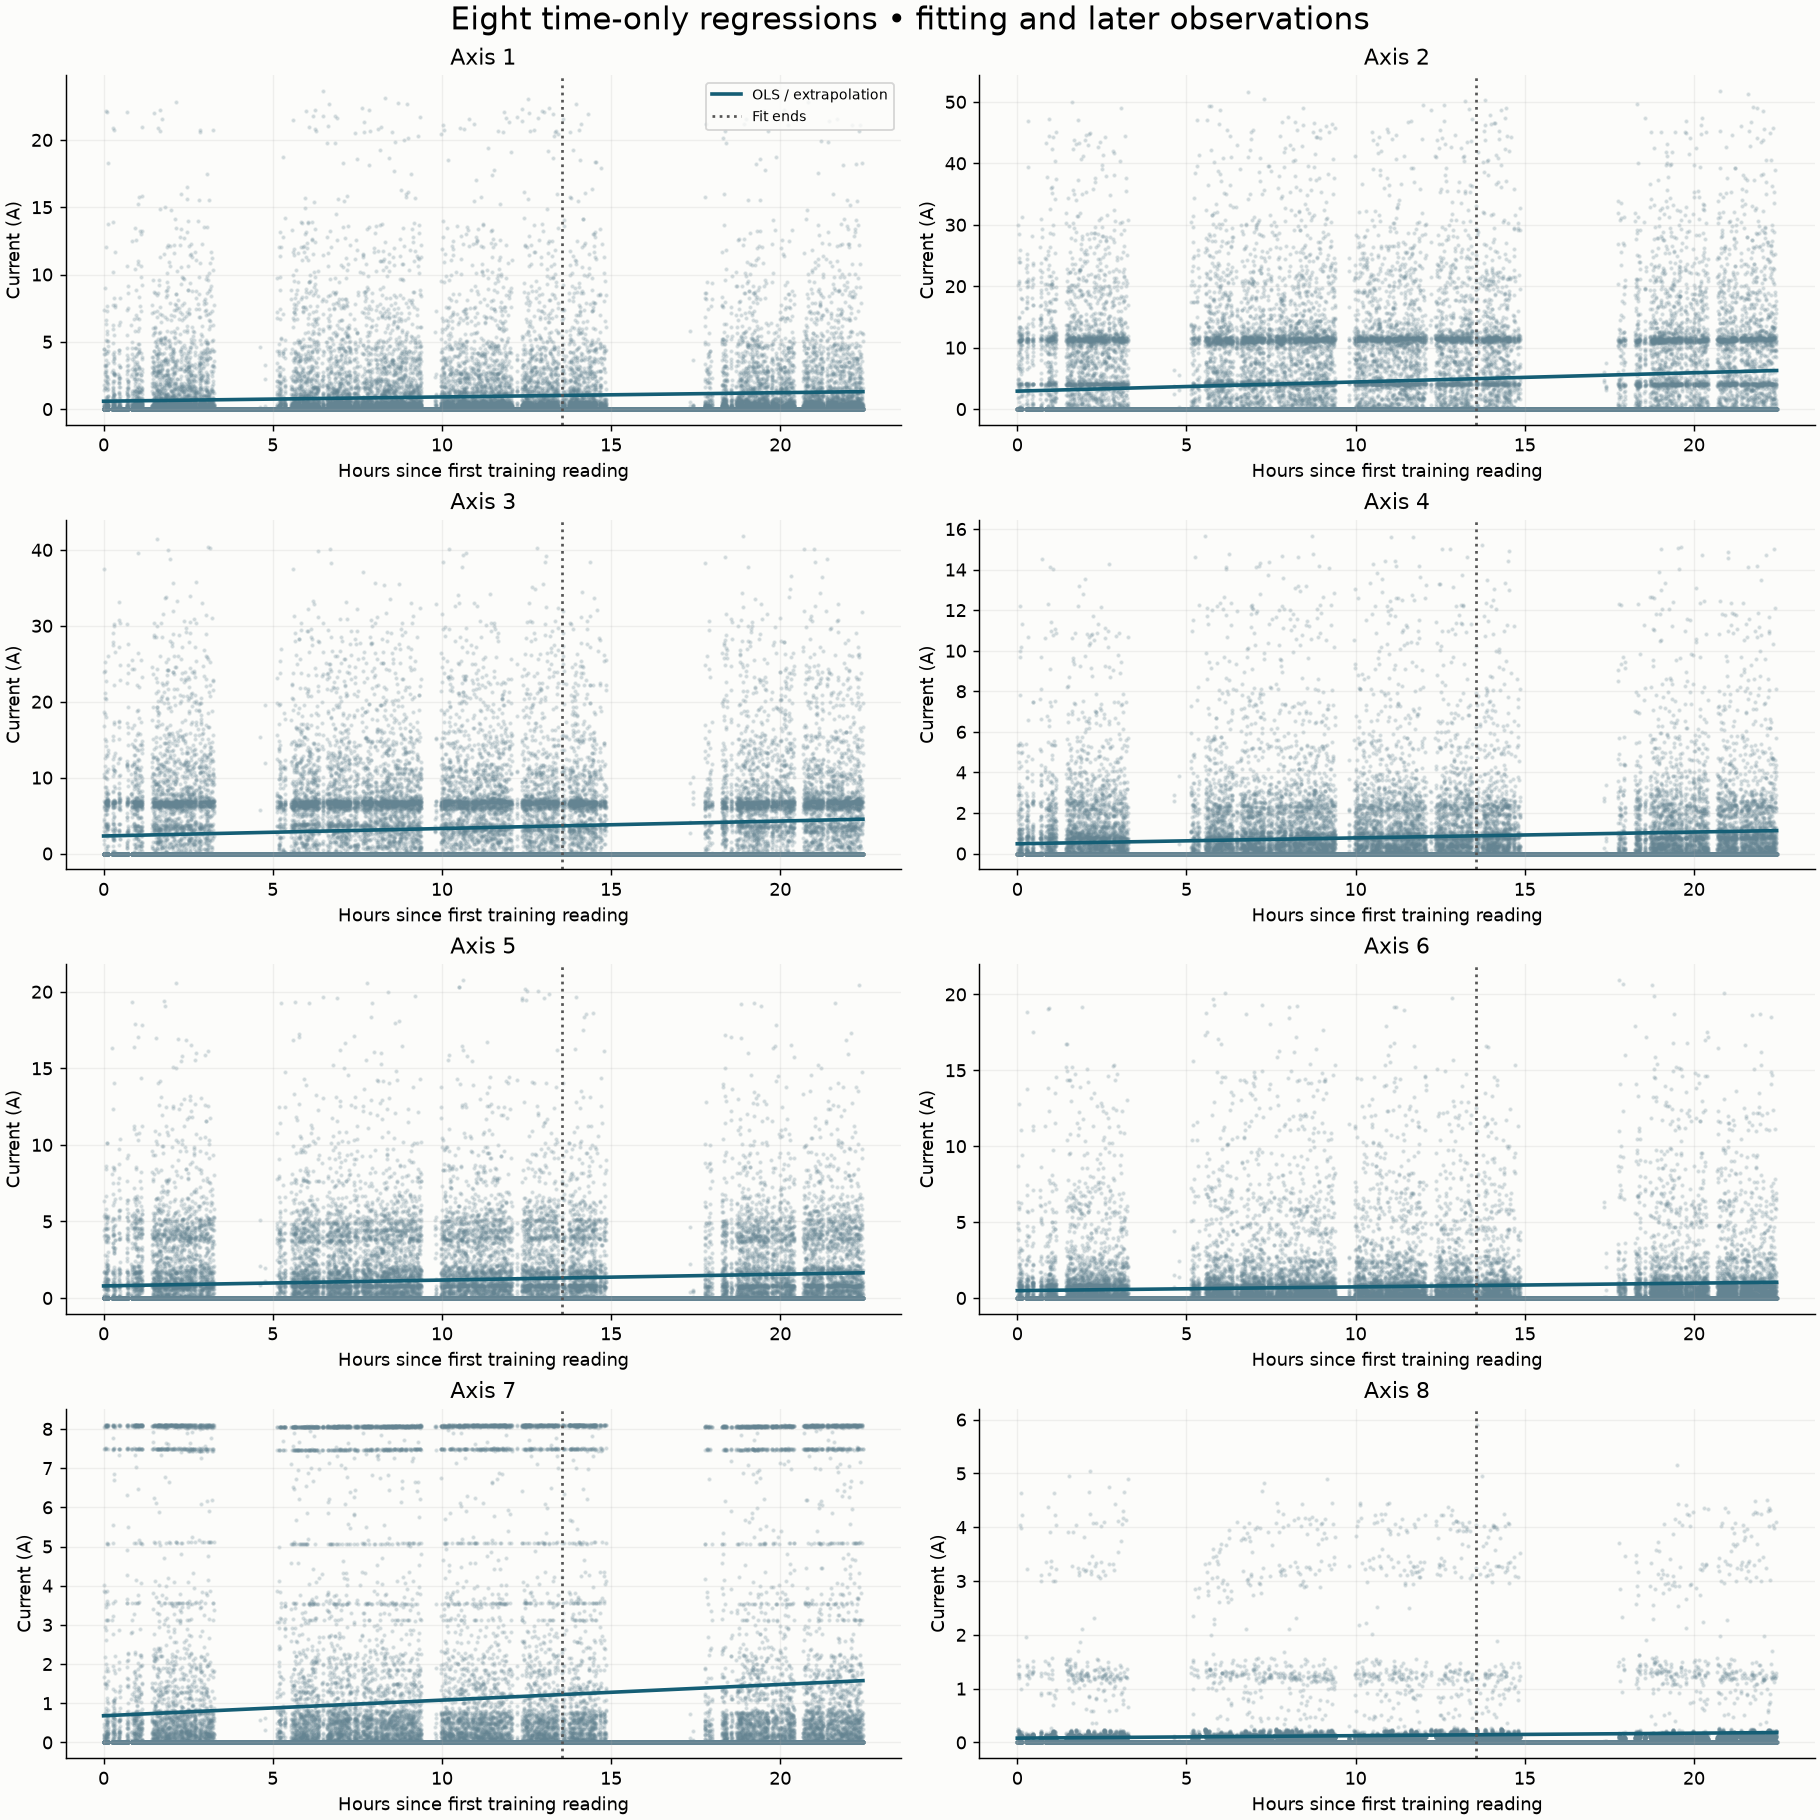

In [7]:
models,origin,coefficients=fit_models(fit)
predictions={name:predict(frame,models,origin) for name,frame in
             (("fit",fit),("calibration",cal),("holdout",holdout))}
residuals={name:frame[AXES]-predictions[name] for name,frame in
           (("fit",fit),("calibration",cal),("holdout",holdout))}
metrics=pd.concat([regression_metrics(frame,predictions[name],name) for name,frame in
                   (("fit",fit),("calibration",cal),("holdout",holdout))],ignore_index=True)
diagnostics=pd.concat([residual_diagnostics(residuals[name],residuals["fit"],name)
                       for name in residuals],ignore_index=True)
display(coefficients)
display(metrics)
plot_regression(data,fit,models,origin,plots/'regressions.png')
display(Image(filename=str(plots/'regressions.png'), width=1050))

#### 4. Find and compare the residuals

A residual is the difference between the actual reading and the prediction:

$$\text{residual} = \text{actual current} - \text{predicted current}$$

For example, if the prediction is 6 A and the reading is 10 A, the residual is +4 A. A positive residual means more current than expected. A negative residual means less. This lab's alerts look for large positive residuals.

We compare the spread of the residuals and count unusually high readings. A Z-score says how many standard deviations a value is from the training average. Here, values above +3 are counted as possible high outliers. The table also shows how many values fall within 1, 2 and 3 standard deviations. These are measured proportions; we do not assume the data follows a normal distribution.

In the calibration set, residual standard deviation is about 4.965 A for axis 2 and 0.300 A for axis 8. This supports using different limits for different axes. Axis 7 has 168 high Z-score outliers, compared with 64 for axis 2 and 52 for axis 8. These are individual readings, not sustained alerts.

We also check the time between readings. A typical training interval is 1.896 seconds. If a gap is longer than 3.0105 seconds, We restart the alert timer. Missing readings cannot show that a high current continued throughout the gap.

In [8]:


def discover_cadence(fit):
    dt = fit.reading_time.diff().dt.total_seconds().dropna()
    return {"median_interval_s": float(dt.median()), "p95_interval_s": float(dt.quantile(.95)),
            "max_gap_s": float(1.5*dt.quantile(.95)),
            "largest_gap_s": float(dt.max()), "gaps_over_limit": int((dt>1.5*dt.quantile(.95)).sum())}

In [9]:
display(diagnostics)
cadence = discover_cadence(fit)
display(pd.Series(cadence, name='Sampling audit'))

,axis,split,mean_A,std_A,q95_A,q99_A,q995_A,skew,lag1_autocorrelation,upper_z3_count,lower_z_minus3_count,proportion_abs_z_le_1,proportion_abs_z_le_2,proportion_abs_z_le_3
0,axis_1,fit,-1.86270e-16,2.28983,3.78181,11.14718,14.15176,4.91665,0.13528,594,0,0.91993,0.95954,0.97505
1,axis_2,fit,-1.71942e-16,7.02869,13.94976,27.84394,35.60951,2.46494,0.51551,513,0,0.84746,0.95047,0.97845
2,axis_3,fit,0.00000e+00,5.27707,10.23012,22.11963,26.01479,2.58230,0.48272,615,0,0.89459,0.95215,0.97416
3,axis_4,fit,3.34331e-17,1.63679,2.63659,8.41671,10.58769,4.29623,0.18498,539,0,0.91018,0.96106,0.97736
4,axis_5,fit,-7.64185e-17,2.18049,4.15194,9.13135,11.61110,3.31597,0.49396,519,0,0.86720,0.95555,0.97820
5,axis_6,fit,1.91046e-17,1.87435,2.85724,10.08548,12.47908,5.00801,0.19071,618,0,0.93534,0.95803,0.97404
6,axis_7,fit,9.55231e-17,2.24601,6.93464,7.31182,7.34374,2.51927,0.28801,1508,0,0.89090,0.91358,0.93665
7,axis_8,fit,-1.13434e-17,0.43985,0.10246,2.98838,3.69565,6.94695,0.20620,370,0,0.96202,0.96597,0.98446
8,axis_1,calibration,-7.67283e-01,1.51876,0.56473,6.99024,10.05794,7.64619,0.21918,82,0,0.96950,0.98374,0.98966
9,axis_2,calibration,-3.75705e+00,4.96509,6.37535,17.96701,25.89698,4.55136,0.59421,64,0,0.96597,0.98172,0.99193


median_interval_s      1.8960
p95_interval_s         2.0070
max_gap_s              3.0105
largest_gap_s        402.5380
gaps_over_limit      751.0000
Name: Sampling audit, dtype: float64

#### 5.Choose MinC, MaxC and T from the data

We need three settings:

| Setting | Meaning |
|---|---|
| `MinC` | How far above the regression line current must rise for an Alert |
| `MaxC` | The larger rise needed for an Error |
| `T` | How long the rise must continue before either rule triggers |

MinC and MaxC are deviations above the line, not total current values. For example, a prediction of 5 A and MinC of 3 A gives an Alert boundary of 8 A.
We calculate limits from the calibration residuals using three percentile pairs: 95/99, 97.5/99.5 and 99/99.9. A 97.5th-percentile limit means that 97.5% of the calibration residuals are at or below it. We calculate these values separately for each axis.
I test T = 2, 6, 10 and 19 seconds. These are rounded-up multiples of the typical training interval. Shorter windows react faster but may treat short bursts as problems. Longer windows ignore more bursts but delay warnings.
For this lab, We choose a target of no more than 1 Alert per hour and 0.25 Errors per hour on any axis during calibration. This is just a comparison target.

The next cell shows the candidate settings, the selected limits and the residual plots. The data has no confirmed failure labels, so these counts show how often the rules fire; they cannot tell which alerts are false alarms.

In [10]:


def excursion_runs(times, values, threshold, max_gap):
    """Vectorized independent reference for offline threshold exploration."""
    times = pd.Series(times).reset_index(drop=True)
    values = np.asarray(values)
    high = np.isfinite(values) & (values >= threshold)
    gaps = times.diff().dt.total_seconds().fillna(np.inf).to_numpy() > max_gap
    starts = np.flatnonzero(high & (np.r_[True, ~high[:-1]] | gaps))
    ends = np.flatnonzero(high & (np.r_[~high[1:], True] | np.r_[gaps[1:], True]))
    return [(int(s), int(e), (times.iloc[e]-times.iloc[s]).total_seconds()) for s,e in zip(starts,ends)]


def threshold_search(cal, residuals, cadence):
    """Choose sensitivity first, then shortest T meeting a stated burden budget."""
    durations = sorted(set(math.ceil(cadence["median_interval_s"]*n) for n in (1,3,5,10)))
    dt = cal.reading_time.diff().dt.total_seconds().fillna(0)
    exposure_h = dt.where(dt<=cadence["max_gap_s"],0).sum()/3600
    records = []
    for qa, qe in ((.95,.99),(.975,.995),(.99,.999)):
        limits = {a:(max(float(residuals[a].quantile(qa)),1e-6),
                     max(float(residuals[a].quantile(qe)),1e-6)) for a in AXES}
        for a,(lo,hi) in limits.items():
            limits[a] = (lo, max(hi,lo+1e-6))
        runs = {(a,level):excursion_runs(cal.reading_time,residuals[a],limits[a][j],cadence["max_gap_s"])
                for a in AXES for j,level in enumerate(("Alert","Error"))}
        for duration in durations:
            for a in AXES:
                ac = sum(d>=duration for _,_,d in runs[a,"Alert"])
                ec = sum(d>=duration for _,_,d in runs[a,"Error"])
                records.append(dict(axis=a, alert_quantile=qa,error_quantile=qe,T_s=duration,
                    MinC_A=limits[a][0], MaxC_A=limits[a][1],
                    calibration_alerts=ac,calibration_errors=ec,
                    alert_events_per_hour=ac/exposure_h,error_events_per_hour=ec/exposure_h,
                    exposure_hours=exposure_h))
    detail = pd.DataFrame(records)
    grid = detail.groupby(["alert_quantile","error_quantile","T_s"],as_index=False).agg(
        calibration_alerts=("calibration_alerts","sum"),calibration_errors=("calibration_errors","sum"),
        worst_axis_alerts_per_hour=("alert_events_per_hour","max"),
        worst_axis_errors_per_hour=("error_events_per_hour","max"))
    grid["meets_budget"] = (grid.worst_axis_alerts_per_hour<=1) & (grid.worst_axis_errors_per_hour<=.25)
    eligible = grid[grid.meets_budget].sort_values(["alert_quantile","error_quantile","T_s"])
    if eligible.empty:
        raise ValueError("No candidate meets the exploratory burden budget. Review grid before extending T.")
    chosen = eligible.iloc[0]
    selected = detail[(detail.alert_quantile==chosen.alert_quantile) &
                      (detail.error_quantile==chosen.error_quantile) & (detail.T_s==chosen.T_s)].copy()
    grid["selected"] = ((grid.alert_quantile==chosen.alert_quantile) &
                        (grid.error_quantile==chosen.error_quantile) & (grid.T_s==chosen.T_s))
    return selected.reset_index(drop=True), detail, grid


def plot_grid(grid,out):
    fig,axs=plt.subplots(1,2,figsize=(12,4.5),constrained_layout=True)
    for (qa,qe),group in grid.groupby(["alert_quantile","error_quantile"]):
        for ax,metric in zip(axs,["worst_axis_alerts_per_hour","worst_axis_errors_per_hour"]):
            ax.plot(group.T_s,group[metric],marker="o",label=f"q{qa*100:g} / q{qe*100:g}")
    for ax,budget,label in zip(axs,[1,.25],["Alerts","Errors"]):
        ax.axhline(budget,color="#555",ls="--",label=f"Budget {budget:g}/h/axis")
        ax.set(xlabel="Continuous duration T (seconds)",ylabel="Worst-axis events / observed hour",title=label)
        ax.legend(fontsize=8)
    fig.suptitle("Threshold sensitivity • calibration burden versus persistence",fontsize=15)
    fig.savefig(out,dpi=150);plt.close(fig)


def plot_residuals(frame,residuals,thresholds,origin,out):
    fig,axs=plt.subplots(4,2,figsize=(14,14),constrained_layout=True)
    for ax,row in zip(axs.flat,thresholds.itertuples()):
        ax.hist(residuals[row.axis],bins=70,color=COLORS["data"],alpha=.8)
        ax.axvline(row.MinC_A,color=COLORS["Alert"],lw=2,label=f"MinC {row.MinC_A:.2f} A")
        ax.axvline(row.MaxC_A,color=COLORS["Error"],lw=2,label=f"MaxC {row.MaxC_A:.2f} A")
        ax.set_yscale("log")
        ax.set(title=row.axis.replace("axis_","Axis "),xlabel="Observed − predicted (A)",ylabel="Count (log scale)")
        ax.legend(fontsize=8)
    fig.suptitle("Calibration residuals • unequal scales and long upper tails",fontsize=17)
    fig.savefig(out,dpi=130);plt.close(fig)
    fig,axs=plt.subplots(4,2,figsize=(14,12),constrained_layout=True)
    hours=time_x(frame,origin).ravel()/3600
    for ax,row in zip(axs.flat,thresholds.itertuples()):
        ax.scatter(hours,residuals[row.axis],s=2,alpha=.3,color=COLORS["data"])
        ax.axhline(row.MinC_A,color=COLORS["Alert"]);ax.axhline(row.MaxC_A,color=COLORS["Error"])
        ax.axhline(0,color="#444",lw=.6)
        ax.set(title=row.axis.replace("axis_","Axis "),xlabel="Hours since first training reading",ylabel="Residual (A)")
    fig.suptitle("Residuals over time • operating bursts remain after regression",fontsize=17)
    fig.savefig(Path(out).with_name("residual_time.png"),dpi=130);plt.close(fig)

,alert_quantile,error_quantile,T_s,calibration_alerts,calibration_errors,worst_axis_alerts_per_hour,worst_axis_errors_per_hour,meets_budget,selected
0,0.950,0.990,2,278,2,15.89573,0.24837,False,False
1,0.950,0.990,6,41,0,6.45764,0.00000,False,False
2,0.950,0.990,10,9,0,1.98697,0.00000,False,False
3,0.950,0.990,19,5,0,1.24185,0.00000,False,False
4,0.975,0.995,2,54,1,3.47719,0.24837,False,False
5,0.975,0.995,6,7,0,1.73860,0.00000,False,False
6,0.975,0.995,10,5,0,1.24185,0.00000,False,False
7,0.975,0.995,19,3,0,0.74511,0.00000,True,True
8,0.990,0.999,2,2,0,0.24837,0.00000,True,False
9,0.990,0.999,6,0,0,0.00000,0.00000,True,False


,axis,MinC_A,MaxC_A,T_s,calibration_alerts,calibration_errors
0,axis_1,2.86812,10.05794,19,0,0
1,axis_2,9.65822,25.89698,19,0,0
2,axis_3,7.15904,20.14127,19,0,0
3,axis_4,1.78572,7.18708,19,0,0
4,axis_5,3.45651,7.94383,19,0,0
5,axis_6,1.64033,8.21076,19,0,0
6,axis_7,6.26705,6.86070,19,0,0
7,axis_8,0.04809,2.96261,19,3,0


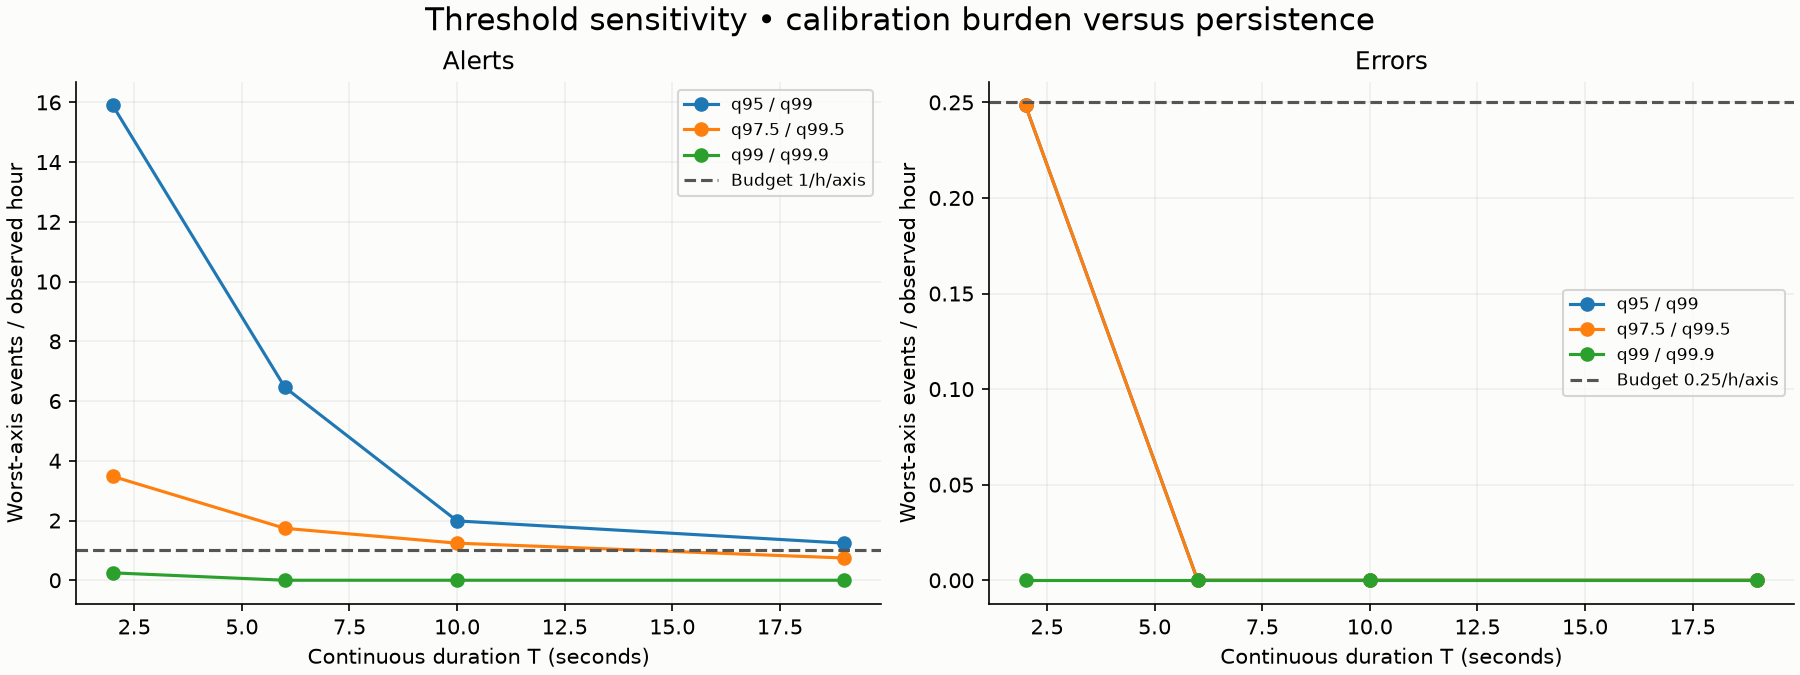

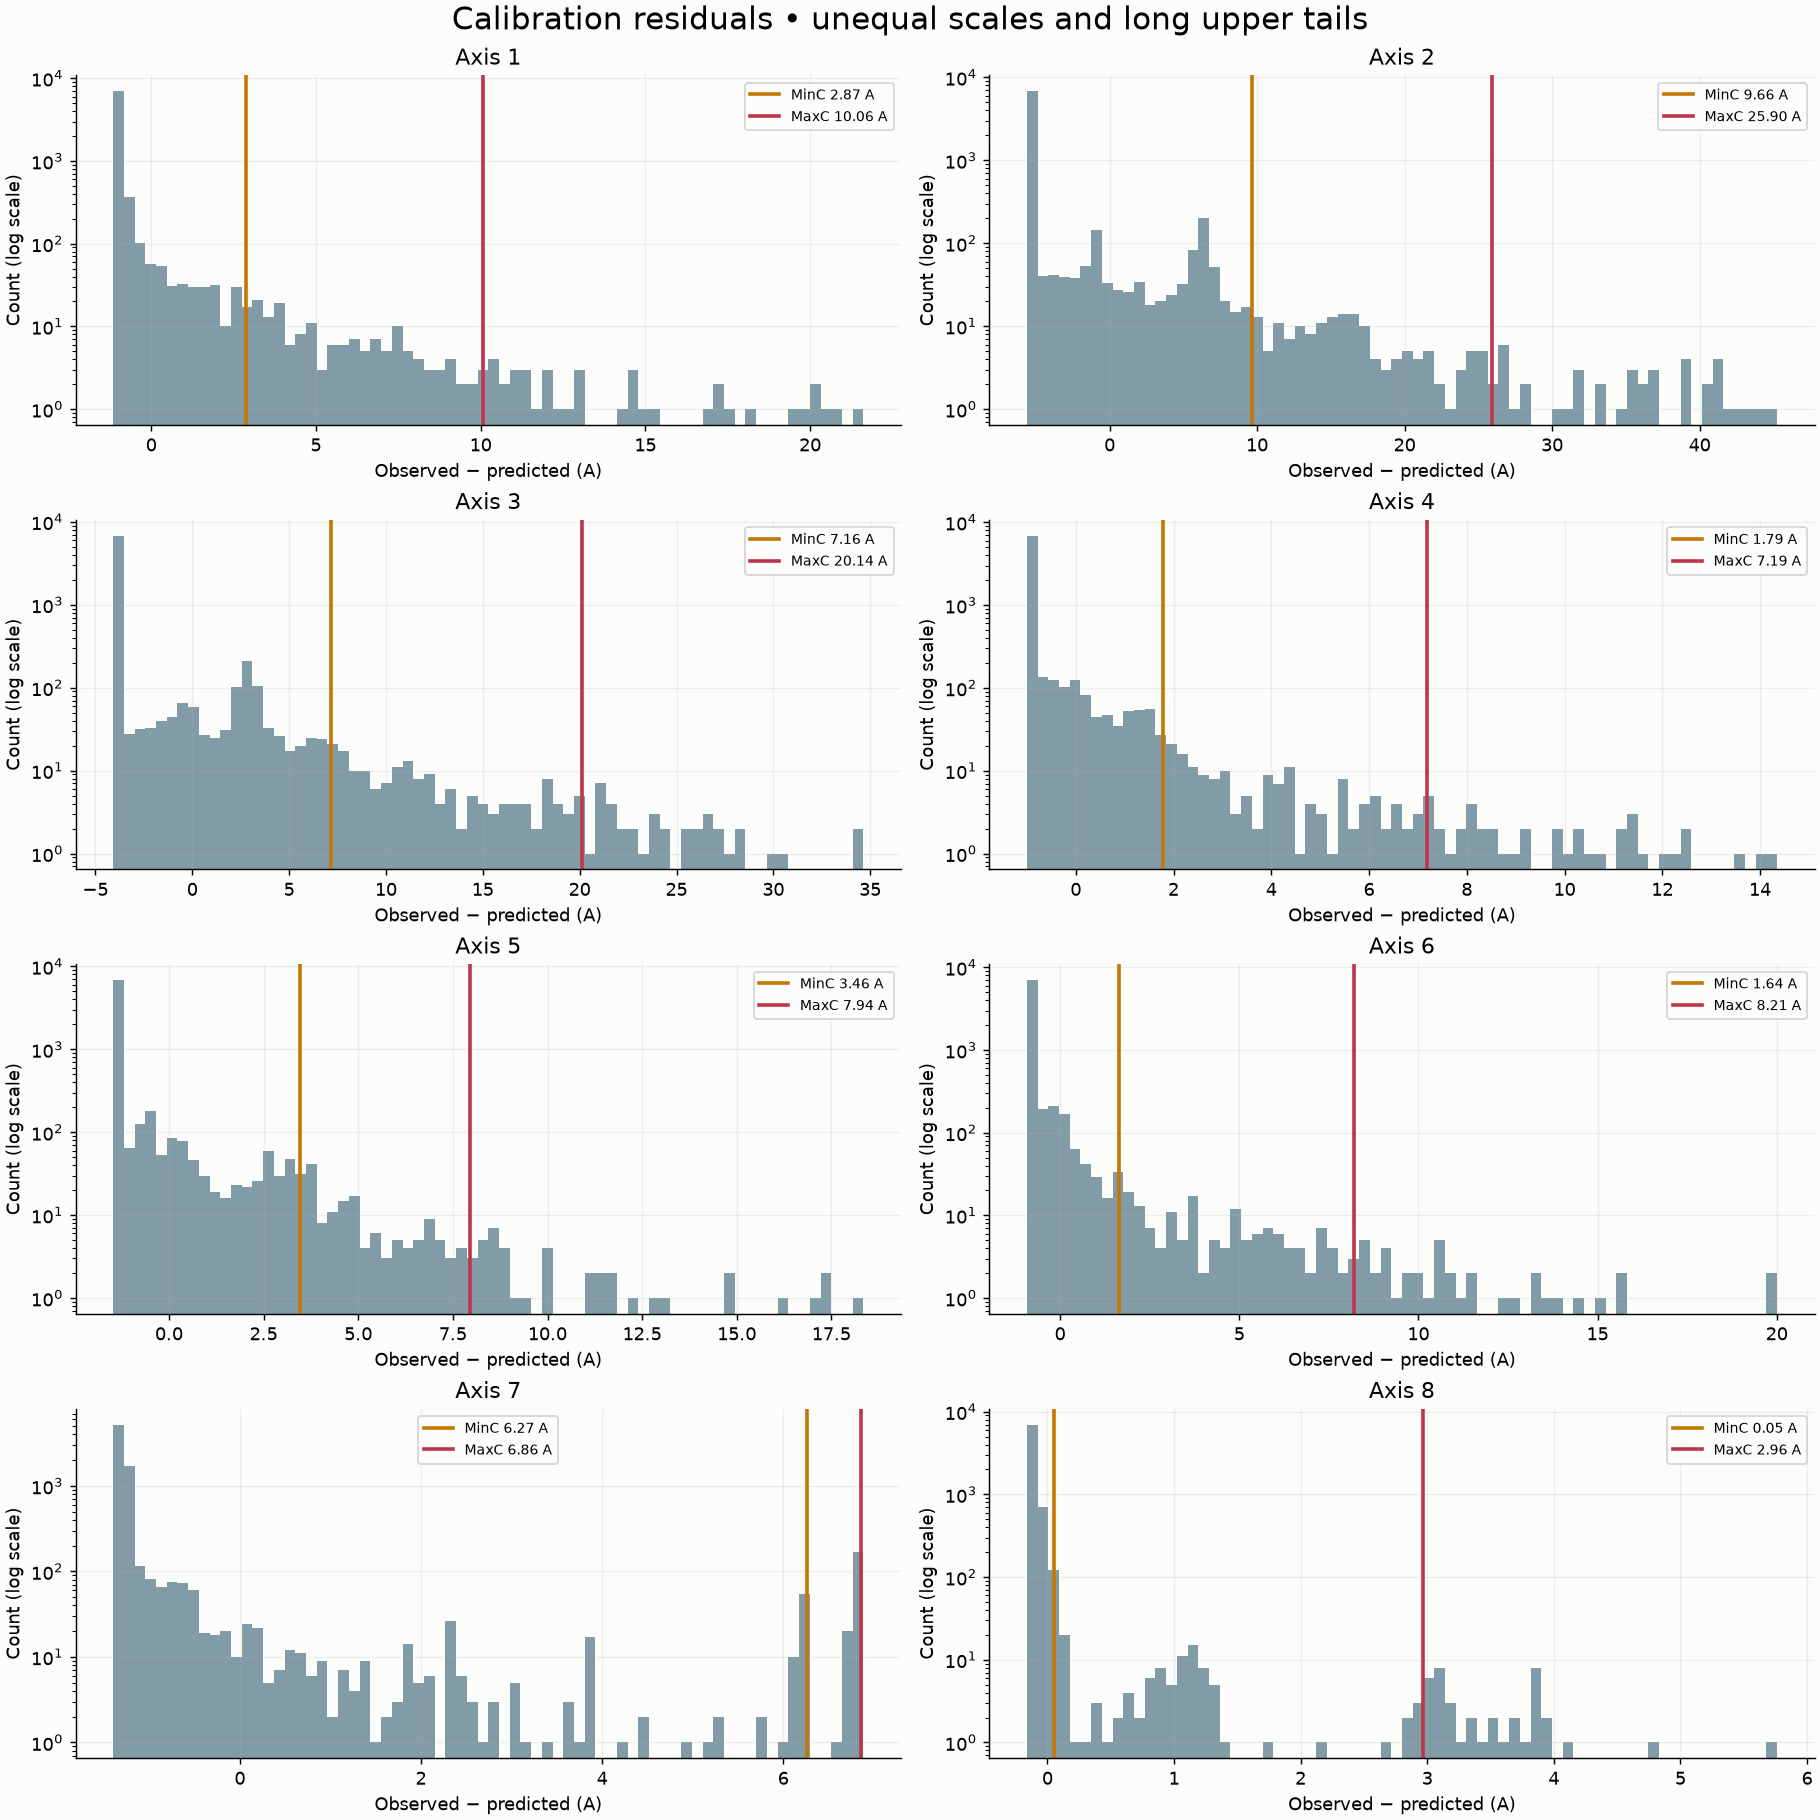

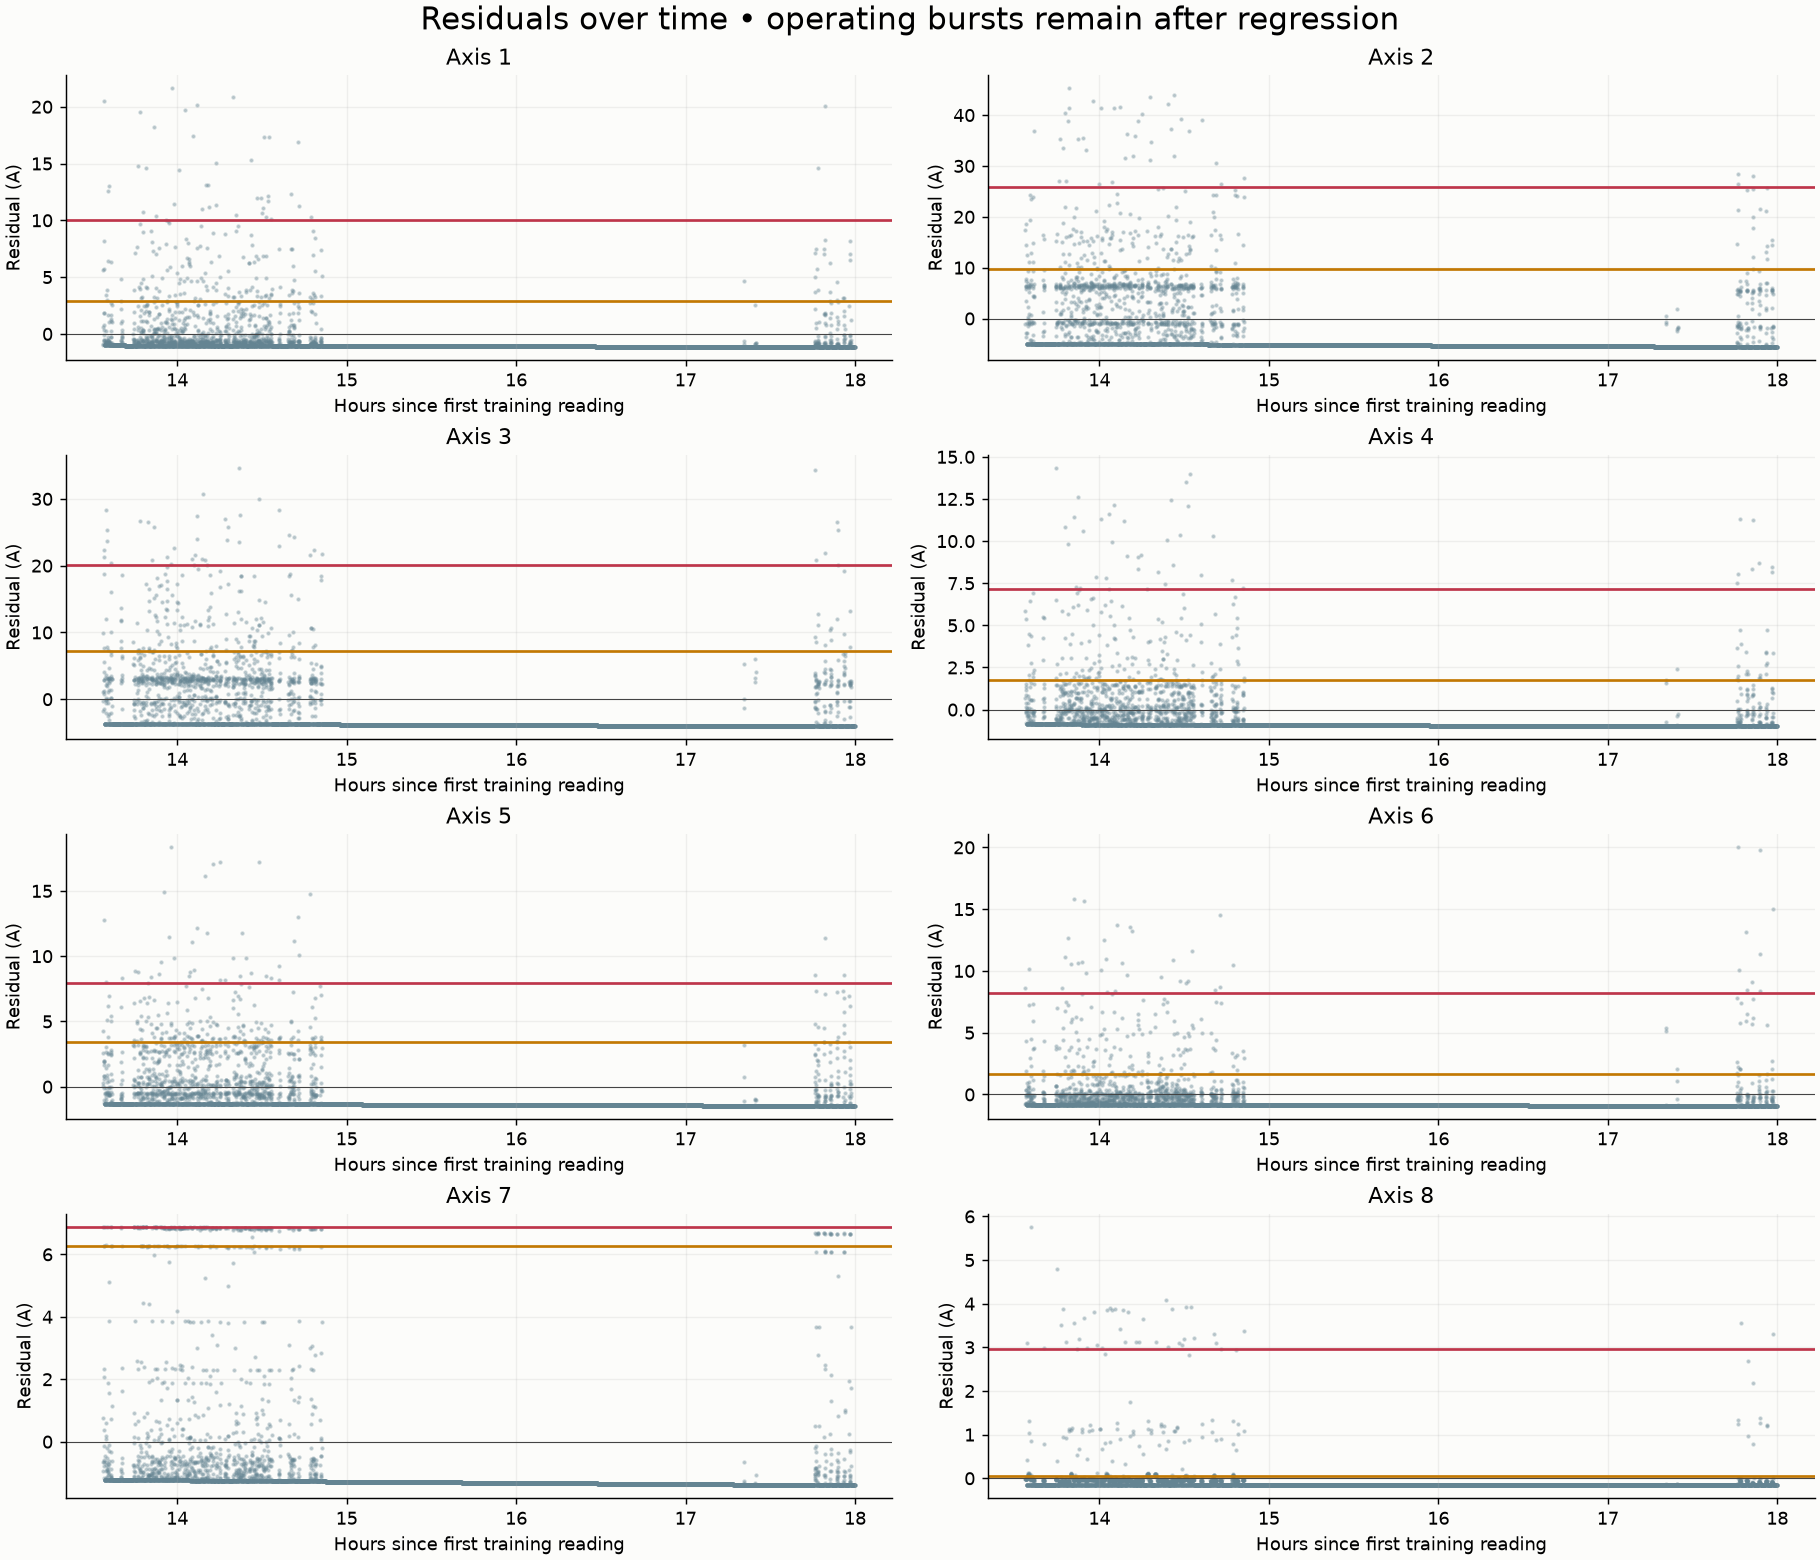

In [11]:
cadence=discover_cadence(fit)
thresholds,detail,grid=threshold_search(cal,residuals["calibration"],cadence)
display(grid)
display(thresholds[['axis','MinC_A','MaxC_A','T_s','calibration_alerts','calibration_errors']])
plot_grid(grid,plots/'threshold_sensitivity.png')
plot_residuals(cal,residuals['calibration'],thresholds,origin,plots/'residual_distributions.png')
display(Image(filename=str(plots/'threshold_sensitivity.png'),width=1050))
display(Image(filename=str(plots/'residual_distributions.png'),width=1050))
display(Image(filename=str(plots/'residual_time.png'),width=1050))

Why these settings are chosen
The comparison gives these results for the axis with the highest Alert rate:

| Percentile pair | T | Alerts per hour | Meets my target? |
|---|---:|---:|---|
| 95 / 99 | 19 s | 1.242 | No |
| 97.5 / 99.5 | 10 s | 1.242 | No |
| 97.5 / 99.5 | 19 s | 0.745 | Yes |
| 99 / 99.9 | 2 s | 0.248 | Yes, but it needs a larger deviation |

We therefore choose the 97.5th percentile for MinC, the 99.5th percentile for MaxC, and T = 19 seconds. This follows my preference for detecting smaller changes that last longer. The 99/99.9 pair is another possible choice if a faster response to larger changes is more important.

The selected current limits are shown in the table above. For example, axis 2 uses MinC ≈ 9.658 A and MaxC ≈ 25.897 A. Axis 8 uses much smaller limits because its normal current is lower.

With these settings, calibration produces three Alerts on axis 8 and no Errors. Axis 7's many individual outliers do not last long enough to produce an event. This shows why we check duration as well as size.

These settings are a starting point . 

#### 6. Create synthetic test data and check scaling

Create two files to test the trained models:

- synthetic_normal.csv contains training readings rearranged in small blocks.
- synthetic_stress.csv starts with that data and adds a long moderate increase, a long large increase and one short spike on each axis.

The files keep the original column names, the current label and the empty axes 9–14. They have new timestamps about 1.896 seconds apart. Each file has 23,803 rows because we use only the training portion to create it. The separate synthetic_ground_truth.csv records where we added the unusual patterns.

We use a fixed random seed so the test can be repeated. The normal file has the same mean and standard deviation as the training portion. Compared with the full original recording, its means differ by about 9–11% and its standard deviations by about 2.5–6.1%. Adding test faults changes these values slightly; the comparison table shows how much.

The test faults are chosen to exercise the Alert and Error rules after the limits are selected. Catching these planned faults checks the code, but it does not prove that every real fault would be caught.

*Min-Max normalization*

Normalization changes the scale using the training minimum and maximum:

$$x_{\text{normalized}}=\frac{x-x_{\min,\text{train}}}{x_{\max,\text{train}}-x_{\min,\text{train}}}$$

Training values fall between 0 and 1. A new test value can be outside this range if it exceeds the training limits.

*Z-score standardization*

Standardization uses the training mean and standard deviation:

$$z=\frac{x-\mu_{\text{train}}}{\sigma_{\text{train}}}$$

A Z-score of +2 means two standard deviations above the training mean. I calculate both sets of scaling values from the training data loaded from Neon, then apply them to both synthetic test files. I do not calculate new scaling values from the test set.
I keep normalization and standardization as two separate versions of the same readings. I do not fit the scalers again on testing data. This keeps test outliers visible instead of letting them change their own comparison scale.

Save scaled test data: the next cell now saves normalized and standardized versions of both the normal and stress files. results/scaling_parameters.json records the training minimum, maximum, mean and standard deviation used.

The current values in those scaled files have no physical unit. We keep the original amp readings too, and use those for regression and alerts. This avoids comparing a Z-score with an amp threshold. During the cloud replay, the same training-based formulas produce both scaled versions for each arriving CSV row, and all three versions are saved to Neon.

In [12]:


def make_synthetic(raw, fit, models, origin, thresholds, cadence, seed=42):
    """Block-bootstrap only fitting rows; exact empirical marginal moments.

    A random permutation of contiguous blocks preserves local patterns and
    cross-axis combinations without fitting to holdout/test values. Blocks
    partition the fitting rows exactly once; mean/std remain identical.
    Test timestamps form a regular ~2s next-day stream. Stress faults are in
    a separate file, with an independent truth table.
    """
    rng = np.random.default_rng(seed)
    residuals = fit[AXES]-predict(fit,models,origin)
    correlations = []
    for lag in range(1,121):
        correlations.append(np.nanmedian([residuals[a].autocorr(lag) for a in AXES]))
    decorrelation = next((i+1 for i,v in enumerate(correlations) if v < .2),120)
    block_size = max(8,decorrelation)
    blocks = [np.arange(i,min(i+block_size,len(fit))) for i in range(0,len(fit),block_size)]
    order = np.concatenate([blocks[i] for i in rng.permutation(len(blocks))])
    normal = fit.iloc[order][["trait",*AXES]].reset_index(drop=True)
    # The source file's final time is metadata only; no evaluation currents enter generation.
    start = pd.to_datetime(raw.Time.iloc[-1],utc=True)+pd.Timedelta(seconds=cadence["median_interval_s"])
    normal["reading_time"] = pd.date_range(start,periods=len(normal),
                                         freq=pd.Timedelta(seconds=cadence["median_interval_s"]))
    stress = normal.copy()
    predicted = predict(stress,models,origin)
    truth = []
    step = cadence["median_interval_s"]
    duration = float(thresholds.T_s.iloc[0])
    fault_n = max(12,math.ceil(4*duration/step)+1)
    for j,row in enumerate(thresholds.itertuples()):
        for k,kind in enumerate(("Alert","Error","Spike")):
            start_i = int(len(stress)*(.10+.09*j))+k*(fault_n+15)
            end_i = start_i+(1 if kind=="Spike" else fault_n)-1
            target = (row.MinC_A+row.MaxC_A)/2 if kind=="Alert" else 1.25*row.MaxC_A
            jitter = rng.uniform(-.04,.04,end_i-start_i+1)*(row.MaxC_A-row.MinC_A)
            # Known, controlled excursions test rule mechanics, not fault forecasting skill.
            stress.loc[start_i:end_i,row.axis] = np.maximum(
                predicted.loc[start_i:end_i,row.axis].to_numpy()+target+jitter,0)
            # Separating samples force episode boundaries for unambiguous truth matching.
            stress.loc[[start_i-1,end_i+1],row.axis] = np.maximum(
                predicted.loc[[start_i-1,end_i+1],row.axis].to_numpy(),0)
            truth.append(dict(axis=row.axis,kind=kind,start_index=start_i,end_index=end_i,
                start_time=stress.reading_time.iloc[start_i],end_time=stress.reading_time.iloc[end_i],
                duration_s=(end_i-start_i)*step,target_residual_A=target))
    def export_schema(frame):
        result = frame.rename(columns={"trait":"Trait","reading_time":"Time",**dict(zip(AXES,RAW_AXES))})
        for i in range(9,15):
            result[f"Axis #{i}"] = np.nan
        result["Time"] = result.Time.dt.strftime("%Y-%m-%dT%H:%M:%S.%fZ").str.replace(r"(\.\d{3})\d+Z$",r"\1Z",regex=True)
        return result[list(raw.columns)]
    meta = dict(seed=seed,method="permuted contiguous fitting-data blocks",block_size=block_size,
                decorrelation_lag=decorrelation,rows=len(normal),cadence_seconds=step,
                start_UTC=start.isoformat(),training_rows_used=len(fit),
                note="Empirical surrogate; original values reused in a new block order. Stress injections change moments.")
    return normal,stress,export_schema(normal),export_schema(stress),pd.DataFrame(truth),meta


def moment_comparison(all_data,fit,normal,stress):
    rows=[]
    for a in AXES:
        row={"axis":a}
        for name,frame in (("source",all_data),("fit",fit),("normal",normal),("stress",stress)):
            row[f"{name}_mean_A"]=frame[a].mean()
            row[f"{name}_std_A"]=frame[a].std()
        row["normal_mean_vs_fit_pct"]=(row["normal_mean_A"]/row["fit_mean_A"]-1)*100
        row["normal_std_vs_fit_pct"]=(row["normal_std_A"]/row["fit_std_A"]-1)*100
        row["normal_mean_vs_source_pct"]=(row["normal_mean_A"]/row["source_mean_A"]-1)*100
        row["normal_std_vs_source_pct"]=(row["normal_std_A"]/row["source_std_A"]-1)*100
        row["stress_mean_vs_fit_pct"]=(row["stress_mean_A"]/row["fit_mean_A"]-1)*100
        row["stress_std_vs_fit_pct"]=(row["stress_std_A"]/row["fit_std_A"]-1)*100
        rows.append(row)
    return pd.DataFrame(rows)


def normalization_demo(fit,normal):
    mm=MinMaxScaler().fit(fit[AXES]);zs=StandardScaler().fit(fit[AXES])
    scaled=mm.transform(normal[AXES]); standardized=zs.transform(normal[AXES])
    return pd.DataFrame([dict(axis=a,fit_min_A=mm.data_min_[j],fit_max_A=mm.data_max_[j],
        fit_mean_A=zs.mean_[j],fit_std_A=zs.scale_[j],test_minmax_min=scaled[:,j].min(),
        test_minmax_max=scaled[:,j].max(),test_z_mean=standardized[:,j].mean(),
        test_z_std=standardized[:,j].std(),test_proportion_abs_z_le_3=(np.abs(standardized[:,j])<=3).mean())
        for j,a in enumerate(AXES)])


def save_scaled_test_data(fit, normal_raw, stress_raw, root, training_source):
    """CODE CHANGE: fit on historical training only, transform both test files.

    Min-Max and Z-score are separate views of the same raw measurements.
    Timestamp, trait and the six empty columns are not transformed.
    """
    root = Path(root)
    mm = MinMaxScaler().fit(fit[AXES])
    zs = StandardScaler().fit(fit[AXES])
    metadata = {
        "training_source": training_source, "training_rows": len(fit),
        "first_training_time": fit.reading_time.iloc[0].isoformat(),
        "last_training_time": fit.reading_time.iloc[-1].isoformat(),
        "raw_unit": "A", "scaled_unit": "dimensionless", "zscore_ddof": 0,
        "axes": {a: {"min_A": float(mm.data_min_[j]), "max_A": float(mm.data_max_[j]),
            "mean_A": float(zs.mean_[j]), "standard_deviation_A": float(np.sqrt(zs.var_[j])),
            "zscore_scale_A": float(zs.scale_[j]),
            "minmax_scale": float(mm.scale_[j]), "minmax_offset": float(mm.min_[j])}
            for j, a in enumerate(AXES)},
        "formula": {"normalized": "raw_A * minmax_scale + minmax_offset",
                    "standardized": "(raw_A - mean_A) / zscore_scale_A"}}
    for name, raw_frame in (("normal", normal_raw), ("stress", stress_raw)):
        currents = raw_frame[RAW_AXES].copy()
        currents.columns = AXES
        for method, scaler in (("normalized", mm), ("standardized", zs)):
            scaled = raw_frame.copy()
            scaled[RAW_AXES] = scaler.transform(currents)
            scaled.to_csv(root / f"data/synthetic_{name}_{method}.csv", index=False)
            # Inverse transform proves that scaling did not change the reading.
            assert np.allclose(scaler.inverse_transform(scaled[RAW_AXES]), currents)
    (root / "results/scaling_parameters.json").write_text(json.dumps(metadata, indent=2))
    return metadata

In [13]:
normal,stress,normal_raw,stress_raw,truth,synthetic_meta=make_synthetic(
    raw,fit,models,origin,thresholds,cadence)
normal_raw.to_csv(root/"data/synthetic_normal.csv",index=False)
stress_raw.to_csv(root/"data/synthetic_stress.csv",index=False)
truth.to_csv(root/"data/synthetic_ground_truth.csv",index=False)
moments=moment_comparison(data,fit,normal,stress)
normalization=normalization_demo(fit,normal)
# fit scales on training only and save both test transformations.
scaling=save_scaled_test_data(fit,normal_raw,stress_raw,root,source)
display(pd.DataFrame(scaling['axes']).T)
print('Saved normalized and standardized versions of both synthetic CSVs.')
display(pd.Series(synthetic_meta,name='Synthetic generation'))
display(moments)
display(normalization)
assert list(normal_raw.columns)==list(raw.columns)
assert normal_raw[[f'Axis #{i}' for i in range(9,15)]].isna().all().all()
assert np.allclose(normal[AXES].mean(),fit[AXES].mean())
assert np.allclose(normal[AXES].std(),fit[AXES].std())
print('Saved normal/stress CSVs and independent ground-truth labels.')

,min_A,max_A,mean_A,standard_deviation_A,zscore_scale_A,minmax_scale,minmax_offset
axis_1,0.0,23.60930,0.80424,2.29307,2.29307,0.04236,0.0
axis_2,0.0,51.66052,3.95211,7.05227,7.05227,0.01936,0.0
axis_3,0.0,41.43384,2.99047,5.29070,5.29070,0.02413,0.0
axis_4,0.0,15.66630,0.68113,1.64057,1.64057,0.06383,0.0
axis_5,0.0,20.75076,1.05133,2.18543,2.18543,0.04819,0.0
axis_6,0.0,20.10552,0.65398,1.87674,1.87674,0.04974,0.0
axis_7,0.0,8.10848,0.95528,2.25128,2.25128,0.12333,0.0
axis_8,0.0,5.04235,0.11147,0.44021,0.44021,0.19832,0.0


Saved normalized and standardized versions of both synthetic CSVs.


seed                                                                 42
method                          permuted contiguous fitting-data blocks
block_size                                                            8
decorrelation_lag                                                     3
rows                                                              23803
cadence_seconds                                                   1.896
start_UTC                              2022-10-18T10:45:00.524000+00:00
training_rows_used                                                23803
note                  Empirical surrogate; original values reused in...
Name: Synthetic generation, dtype: object

,axis,source_mean_A,source_std_A,fit_mean_A,fit_std_A,normal_mean_A,normal_std_A,stress_mean_A,stress_std_A,normal_mean_vs_fit_pct,normal_std_vs_fit_pct,normal_mean_vs_source_pct,normal_std_vs_source_pct,stress_mean_vs_fit_pct,stress_std_vs_fit_pct
0,axis_1,0.72574,2.16212,0.80424,2.29312,0.80424,2.29312,0.84155,2.37546,0.00000e+00,0.00000e+00,10.81648,6.05877,4.63856,3.59104
1,axis_2,3.61337,6.87996,3.95211,7.05241,3.95211,7.05241,4.06076,7.25164,0.00000e+00,0.00000e+00,9.37438,2.50660,2.74921,2.82486
2,axis_3,2.71034,5.11190,2.99047,5.29081,2.99047,5.29081,3.06267,5.44067,0.00000e+00,2.22045e-14,10.33571,3.49991,2.41430,2.83246
3,axis_4,0.62022,1.57490,0.68113,1.64061,0.68113,1.64061,0.70611,1.69926,0.00000e+00,0.00000e+00,9.81958,4.17228,3.66876,3.57531
4,axis_5,0.95452,2.10019,1.05133,2.18548,1.05133,2.18548,1.08472,2.24709,-2.22045e-14,0.00000e+00,10.14266,4.06104,3.17529,2.81952
5,axis_6,0.59943,1.81550,0.65398,1.87678,0.65398,1.87678,0.68280,1.94212,0.00000e+00,0.00000e+00,9.10117,3.37541,4.40579,3.48172
6,axis_7,0.87015,2.16681,0.95528,2.25132,0.95528,2.25132,0.98466,2.30364,2.22045e-14,0.00000e+00,9.78410,3.90029,3.07531,2.32400
7,axis_8,0.10221,0.42308,0.11147,0.44022,0.11147,0.44022,0.12135,0.47317,0.00000e+00,0.00000e+00,9.05095,4.05193,8.86368,7.48543


,axis,fit_min_A,fit_max_A,fit_mean_A,fit_std_A,test_minmax_min,test_minmax_max,test_z_mean,test_z_std,test_proportion_abs_z_le_3
0,axis_1,0.0,23.60930,0.80424,2.29307,0.0,1.0,-7.88066e-17,1.0,0.97500
1,axis_2,0.0,51.66052,3.95211,7.05227,0.0,1.0,3.82092e-17,1.0,0.97828
2,axis_3,0.0,41.43384,2.99047,5.29070,0.0,1.0,1.31344e-17,1.0,0.97395
3,axis_4,0.0,15.66630,0.68113,1.64057,0.0,1.0,4.71645e-17,1.0,0.97757
4,axis_5,0.0,20.75076,1.05133,2.18543,0.0,1.0,2.71644e-17,1.0,0.97799
5,axis_6,0.0,20.10552,0.65398,1.87674,0.0,1.0,2.38808e-17,1.0,0.97408
6,axis_7,0.0,8.10848,0.95528,2.25128,0.0,1.0,5.61198e-17,1.0,0.94001
7,axis_8,0.0,5.04235,0.11147,0.44021,0.0,1.0,-3.34331e-17,1.0,0.98441


Saved normal/stress CSVs and independent ground-truth labels.


#### 7. Predict each reading and check the Alert and Error rules

For this comparison, we pass each DataFrame row to the detector.  The StreamingSimulator calls the same prediction step while reading the CSV. For each reading, we calculate the predicted current and its residual using the trained model.

- Alert: residual ≥ MinC continuously for at least 19 seconds.
- Error: residual ≥ MaxC continuously for at least 19 seconds.

Each axis has its own timers. A reading below a limit resets that limit's timer. Missing values or a long time gap also interrupt the evidence. I use the timestamp difference to measure duration, not just the number of rows.

The Error timer is separate from the Alert timer. Spending 19 seconds above MinC does not mean an Error should happen immediately when MaxC is crossed.

The detector gives its first notification when the required time has passed. With test readings 1.896 seconds apart, the first reading after 19 seconds arrives at 20.856 seconds. That is the detection delay in this test.

An Error-level increase can satisfy both rules, so it may create an Alert record and an Error record for the same incident. If the stream ends before recovery is seen, the log marks the duration as unfinished (right_censored).

For the full-data comparison below, we replay without waiting so the analysis finishes quickly. We also demonstrate a CSV-to-database stream with actual pauses. Both use the same prediction callback and timestamps for the alert timers.

Shared callback: the normal replay and the new timed database replay now use the same prediction_callback(). This keeps the prediction and Alert/Error rules consistent.

In [14]:

"""Causal, event-time threshold timers; no future readings are consulted."""
from dataclasses import dataclass
import math
import pandas as pd

EVENT_COLUMNS = ["event_id", "axis", "severity", "start_time", "trigger_time",
                 "end_time", "duration_s", "detection_delay_s", "threshold_A",
                 "peak_residual_A", "sample_count", "end_reason", "right_censored"]


@dataclass
class Rule:
    min_c: float
    max_c: float
    duration_s: float

    def __post_init__(self):
        if not (0 < self.min_c < self.max_c and self.duration_s > 0):
            raise ValueError("Require 0 < MinC < MaxC and T > 0.")


class SustainedDetector:
    """Independent Alert/Error timers preserve both inclusive threshold rules.

    Returned notifications occur at first confirmation. Completed events carry
    the final observed duration. Error may overlap Alert for the same episode.
    A finite sample below a threshold, invalid value, or large gap resets it.
    Duplicate/out-of-order timestamps are rejected, never counted as persistence.
    """
    def __init__(self, rules, max_gap_s):
        if max_gap_s <= 0:
            raise ValueError("max_gap_s must be positive")
        self.rules = rules
        self.max_gap_s = max_gap_s
        self.previous = None
        self.active = {}
        self.events = []
        self.notifications = []
        self.counter = 0

    def _finish(self, key, reason):
        state = self.active.pop(key, None)
        if state and state["trigger_time"] is not None:
            state["duration_s"] = (state["end_time"] - state["start_time"]).total_seconds()
            state["end_reason"] = reason
            state["right_censored"] = reason in ("stream_end", "gap", "invalid")
            self.events.append(state)

    def update(self, timestamp, residuals):
        t = pd.Timestamp(timestamp)
        if pd.isna(t) or t.tzinfo is None:
            raise ValueError("Use a valid timezone-aware event timestamp.")
        if self.previous is not None and t <= self.previous:
            raise ValueError("Event timestamps must be strictly increasing.")
        if self.previous is not None and (t - self.previous).total_seconds() > self.max_gap_s:
            for key in list(self.active):
                self._finish(key, "gap")
        emitted = []
        for axis, rule in self.rules.items():
            value = float(residuals.get(axis, float("nan")))
            for severity, threshold in (("Alert", rule.min_c), ("Error", rule.max_c)):
                key = axis, severity
                if not math.isfinite(value) or value < threshold:
                    self._finish(key, "invalid" if not math.isfinite(value) else "below_threshold")
                    continue
                if key not in self.active:
                    self.counter += 1
                    self.active[key] = dict(
                        event_id=self.counter, axis=axis, severity=severity,
                        start_time=t, trigger_time=None, end_time=t,
                        duration_s=0.0, detection_delay_s=None, threshold_A=threshold,
                        peak_residual_A=value, sample_count=0,
                        end_reason=None, right_censored=False)
                state = self.active[key]
                state["end_time"] = t
                state["sample_count"] += 1
                state["peak_residual_A"] = max(value, state["peak_residual_A"])
                elapsed = (t - state["start_time"]).total_seconds()
                if state["trigger_time"] is None and elapsed >= rule.duration_s:
                    state["trigger_time"] = t
                    state["detection_delay_s"] = elapsed
                    notice = {**state, "duration_s": elapsed}
                    self.notifications.append(notice)
                    emitted.append(notice)
        self.previous = t
        return emitted

    def finish(self):
        for key in list(self.active):
            self._finish(key, "stream_end")
        return pd.DataFrame(self.events, columns=EVENT_COLUMNS)


In [15]:


def make_rules(thresholds):
    return {r.axis:Rule(r.MinC_A,r.MaxC_A,r.T_s) for r in thresholds.itertuples()}


def prediction_callback(models, origin, thresholds, cadence):
    """CODE CHANGE: reuse this per-reading predictor in CSV and cloud replays."""
    detector = SustainedDetector(make_rules(thresholds),cadence["max_gap_s"])
    slopes = np.array([models[a].coef_[0] for a in AXES])
    intercepts = np.array([models[a].intercept_ for a in AXES])
    prediction_rows = []
    def on_tick(record):
        t = pd.Timestamp(record["reading_time"])
        expected = slopes*(t-origin).total_seconds()+intercepts
        residuals = np.array([record[a] for a in AXES])-expected
        notices = detector.update(t,dict(zip(AXES,residuals)))
        prediction_rows.append({"reading_time":t,
            **{f"{a}_prediction_A":float(expected[j]) for j,a in enumerate(AXES)},
            **{f"{a}_residual_A":float(residuals[j]) for j,a in enumerate(AXES)},
            "new_notifications":len(notices)})
    return detector, on_tick, prediction_rows


def stream_detect(frame, models, origin, thresholds, cadence):
    detector, on_tick, prediction_rows = prediction_callback(models, origin, thresholds, cadence)
    for record in frame.to_dict("records"):
        on_tick(record)
    return detector.finish(), pd.DataFrame(detector.notifications), pd.DataFrame(prediction_rows)


def match_truth(truth,events):
    results=[]
    for row in truth.itertuples():
        candidates=events[(events.axis==row.axis)&(events.trigger_time>=row.start_time)&
                          (events.trigger_time<=row.end_time)] if len(events) else events
        target="Alert" if row.kind=="Alert" else "Error"
        matches=(candidates if row.kind=="Spike" else candidates[candidates.severity==target]) if len(candidates) else candidates
        results.append(dict(axis=row.axis,scenario=row.kind,expected_event=row.kind!="Spike",
            detected=bool(len(matches)),
            detection_delay_s=(matches.trigger_time.min()-row.start_time).total_seconds() if len(matches) else np.nan))
    return pd.DataFrame(results)

In [16]:
event_frames={};summaries=[]
for name,frame in (("calibration",cal),("holdout",holdout),("synthetic_normal",normal),("synthetic_stress",stress)):
    events,notices,predicted=stream_detect(frame,models,origin,thresholds,cadence)
    event_frames[name]=events
    save_table(events,root,f"{name}_events.csv")
    if name=="synthetic_stress":
        save_table(notices,root,"stream_notifications.csv")
        save_table(predicted,root,"stream_predictions.csv")
    for axis in AXES:
        subset=events[events.axis==axis]
        summaries.append(dict(dataset=name,axis=axis,rows=len(frame),
            alerts=int((subset.severity=="Alert").sum()),errors=int((subset.severity=="Error").sum())))
counts=pd.DataFrame(summaries)
# The independently calculated run counts must agree with the state machine.
actual=counts[counts.dataset=="calibration"].set_index("axis")
expected=thresholds.set_index("axis")
assert np.array_equal(actual.loc[AXES,"alerts"],expected.loc[AXES,"calibration_alerts"])
assert np.array_equal(actual.loc[AXES,"errors"],expected.loc[AXES,"calibration_errors"])
evaluation=match_truth(truth,event_frames["synthetic_stress"])
dataset_order=["calibration","holdout","synthetic_normal","synthetic_stress"]
counts_table=counts.pivot(index="axis",columns="dataset",values=["alerts","errors"])
counts_table=counts_table.reindex(columns=pd.MultiIndex.from_product([["alerts","errors"],dataset_order]))
counts_table.columns=pd.MultiIndex.from_tuples(
    [(category.title(),dataset) for category,dataset in counts_table.columns],
    names=["", "Dataset"])
counts_table.index.name="Axis"
from IPython.display import HTML
display(HTML(counts_table.to_html()))
display(evaluation)
display(event_frames['synthetic_stress'][['axis','severity','start_time','trigger_time','end_time','duration_s','detection_delay_s','peak_residual_A']])

,axis,scenario,expected_event,detected,detection_delay_s
0,axis_1,Alert,True,True,20.856
1,axis_1,Error,True,True,20.856
2,axis_1,Spike,False,False,NaN
3,axis_2,Alert,True,True,20.856
4,axis_2,Error,True,True,20.856
5,axis_2,Spike,False,False,NaN
6,axis_3,Alert,True,True,20.856
7,axis_3,Error,True,True,20.856
8,axis_3,Spike,False,False,NaN
9,axis_4,Alert,True,True,20.856


,axis,severity,start_time,trigger_time,end_time,duration_s,detection_delay_s,peak_residual_A
0,axis_1,Alert,2022-10-18 12:00:13.004000+00:00,2022-10-18 12:00:33.860000+00:00,2022-10-18 12:01:30.740000+00:00,77.736,20.856,6.75049
1,axis_1,Alert,2022-10-18 12:02:01.076000+00:00,2022-10-18 12:02:21.932000+00:00,2022-10-18 12:03:18.812000+00:00,77.736,20.856,12.85238
2,axis_1,Error,2022-10-18 12:02:01.076000+00:00,2022-10-18 12:02:21.932000+00:00,2022-10-18 12:03:18.812000+00:00,77.736,20.856,12.85238
3,axis_2,Alert,2022-10-18 13:07:54.236000+00:00,2022-10-18 13:08:15.092000+00:00,2022-10-18 13:09:11.972000+00:00,77.736,20.856,18.42067
4,axis_2,Alert,2022-10-18 13:09:42.308000+00:00,2022-10-18 13:10:03.164000+00:00,2022-10-18 13:11:00.044000+00:00,77.736,20.856,33.00263
5,axis_2,Error,2022-10-18 13:09:42.308000+00:00,2022-10-18 13:10:03.164000+00:00,2022-10-18 13:11:00.044000+00:00,77.736,20.856,33.00263
6,axis_3,Alert,2022-10-18 14:15:35.468000+00:00,2022-10-18 14:15:56.324000+00:00,2022-10-18 14:16:53.204000+00:00,77.736,20.856,14.16035
7,axis_3,Alert,2022-10-18 14:17:23.540000+00:00,2022-10-18 14:17:44.396000+00:00,2022-10-18 14:18:41.276000+00:00,77.736,20.856,25.66949
8,axis_3,Error,2022-10-18 14:17:23.540000+00:00,2022-10-18 14:17:44.396000+00:00,2022-10-18 14:18:41.276000+00:00,77.736,20.856,25.66949
9,axis_4,Alert,2022-10-18 15:23:18.596000+00:00,2022-10-18 15:23:39.452000+00:00,2022-10-18 15:24:36.332000+00:00,77.736,20.856,4.67831


#### 8. Check the test results and compare settings

Now applying the same candidate settings to the synthetic stress data. This shows how changing the limits or T changes the number of events. we keep the final settings chosen from calibration; we do not change them to improve the synthetic test result.
With the selected settings:
- All eight long Alert-level increases are detected.
- All eight long Error-level increases are detected.
- All eight single-reading spikes are ignored because they do not last long enough.
The event log has 16 Alert records and 8 Error records. There are only 16 sustained test incidents: the eight Error incidents also satisfy the Alert rule.
The normal synthetic data and real holdout data produce no sustained events. This tells  that none of those readings met the selected rules. It does not prove that the robot has no faults.

In [17]:
# Explore the same fixed stress stream under every candidate. Do not retune.
sweep=[]
stress_res=stress[AXES]-predict(stress,models,origin)
for row in detail.itertuples():
    ac=sum(d>=row.T_s for _,_,d in excursion_runs(stress.reading_time,stress_res[row.axis],row.MinC_A,cadence["max_gap_s"]))
    ec=sum(d>=row.T_s for _,_,d in excursion_runs(stress.reading_time,stress_res[row.axis],row.MaxC_A,cadence["max_gap_s"]))
    sweep.append(dict(axis=row.axis,alert_quantile=row.alert_quantile,error_quantile=row.error_quantile,
                      T_s=row.T_s,stress_alerts=ac,stress_errors=ec))
stress_sweep=pd.DataFrame(sweep)
stress_summary=(
    stress_sweep.groupby(["alert_quantile","error_quantile","T_s"],as_index=False)
    [["stress_alerts","stress_errors"]].sum()
)
stress_summary["alert_quantile"]=stress_summary["alert_quantile"].map(lambda value: f"{value:.3f}")
stress_summary["error_quantile"]=stress_summary["error_quantile"].map(lambda value: f"{value:.3f}")
stress_summary["T_s"]=stress_summary["T_s"].map(lambda value: f"{value:g}")
stress_summary.columns=pd.MultiIndex.from_tuples([
    ("", "alert_quantile"),
    ("", "error_quantile"),
    ("", "T_s"),
    ("stress_alerts", ""),
    ("stress_errors", ""),
])
from IPython.display import HTML
display(HTML(stress_summary.to_html(index=False, escape=False)))

### 9. Show the results and save the event logs

Each plot below shows one axis:
- The current trace shows the synthetic readings.
- The regression line shows the expected current.
- The dashed lines show the Alert and Error boundaries.
- Triangles mark Alert confirmation; crosses mark Error confirmation.
- Labels show how long each increase lasted.

The plots focus on the section containing the added test patterns so the markers are easy to see.

We also save the results as CSV files. stream_predictions.csv contains predictions and residuals. stream_notifications.csv records when a rule first triggers. synthetic_stress_events.csv records the axis, severity, start and end times, duration, limit and highest residual. Separate event files keep the calibration, real test and synthetic normal results apart.

This gives a maintenance team both a visual warning and a record it can review later.

In [18]:


def plot_events(stress,models,origin,thresholds,truth,events,out):
    predicted=predict(stress,models,origin)
    fig,axs=plt.subplots(4,2,figsize=(15,15),constrained_layout=True)
    for ax,row in zip(axs.flat,thresholds.itertuples()):
        cases=truth[truth.axis==row.axis]
        start_i=max(0,int(cases.start_index.min())-10);end_i=min(len(stress)-1,int(cases.end_index.max())+10)
        sl=slice(start_i,end_i+1)
        t0=stress.reading_time.iloc[start_i]
        x=(stress.reading_time.iloc[sl]-t0).dt.total_seconds()
        ax.plot(x,stress[row.axis].iloc[sl],color=COLORS["data"],lw=1,label="Observed")
        ax.plot(x,predicted[row.axis].iloc[sl],color=COLORS["line"],lw=1.8,label="Regression")
        for lev,val in (("Alert",row.MinC_A),("Error",row.MaxC_A)):
            ax.plot(x,predicted[row.axis].iloc[sl]+val,color=COLORS[lev],ls="--",lw=1,label=lev+" boundary")
        shown=events[(events.axis==row.axis)&(events.trigger_time>=t0)&
                     (events.trigger_time<=stress.reading_time.iloc[end_i])]
        for count,e in enumerate(shown.itertuples()):
            idx=stress.reading_time.searchsorted(e.trigger_time)
            tx=(e.trigger_time-t0).total_seconds();ty=stress[row.axis].iloc[idx]
            ax.scatter(tx,ty,marker="^" if e.severity=="Alert" else "X",s=65,color=COLORS[e.severity],zorder=5)
            ax.annotate(f"{e.severity}: {e.duration_s:.1f}s",(tx,ty),
                xytext=(6,15+17*(count%2)),textcoords="offset points",fontsize=8,
                color=COLORS[e.severity],arrowprops=dict(arrowstyle="-",color=COLORS[e.severity]))
        spike=cases[cases.kind=="Spike"].iloc[0]
        sx=(spike.start_time-t0).total_seconds()
        ax.text(sx,ax.get_ylim()[0],"spike",ha="center",va="bottom",fontsize=8)
        ax.margins(y=.35)
        ax.set(title=row.axis.replace("axis_","Axis "),xlabel="Seconds within scenario window",ylabel="Current (A)")
    axs.flat[0].legend(loc="lower left",fontsize=7,ncol=2)
    fig.suptitle("Streaming detections • markers at confirmation, labels show observed event duration",fontsize=16)
    fig.savefig(out,dpi=140);plt.close(fig)

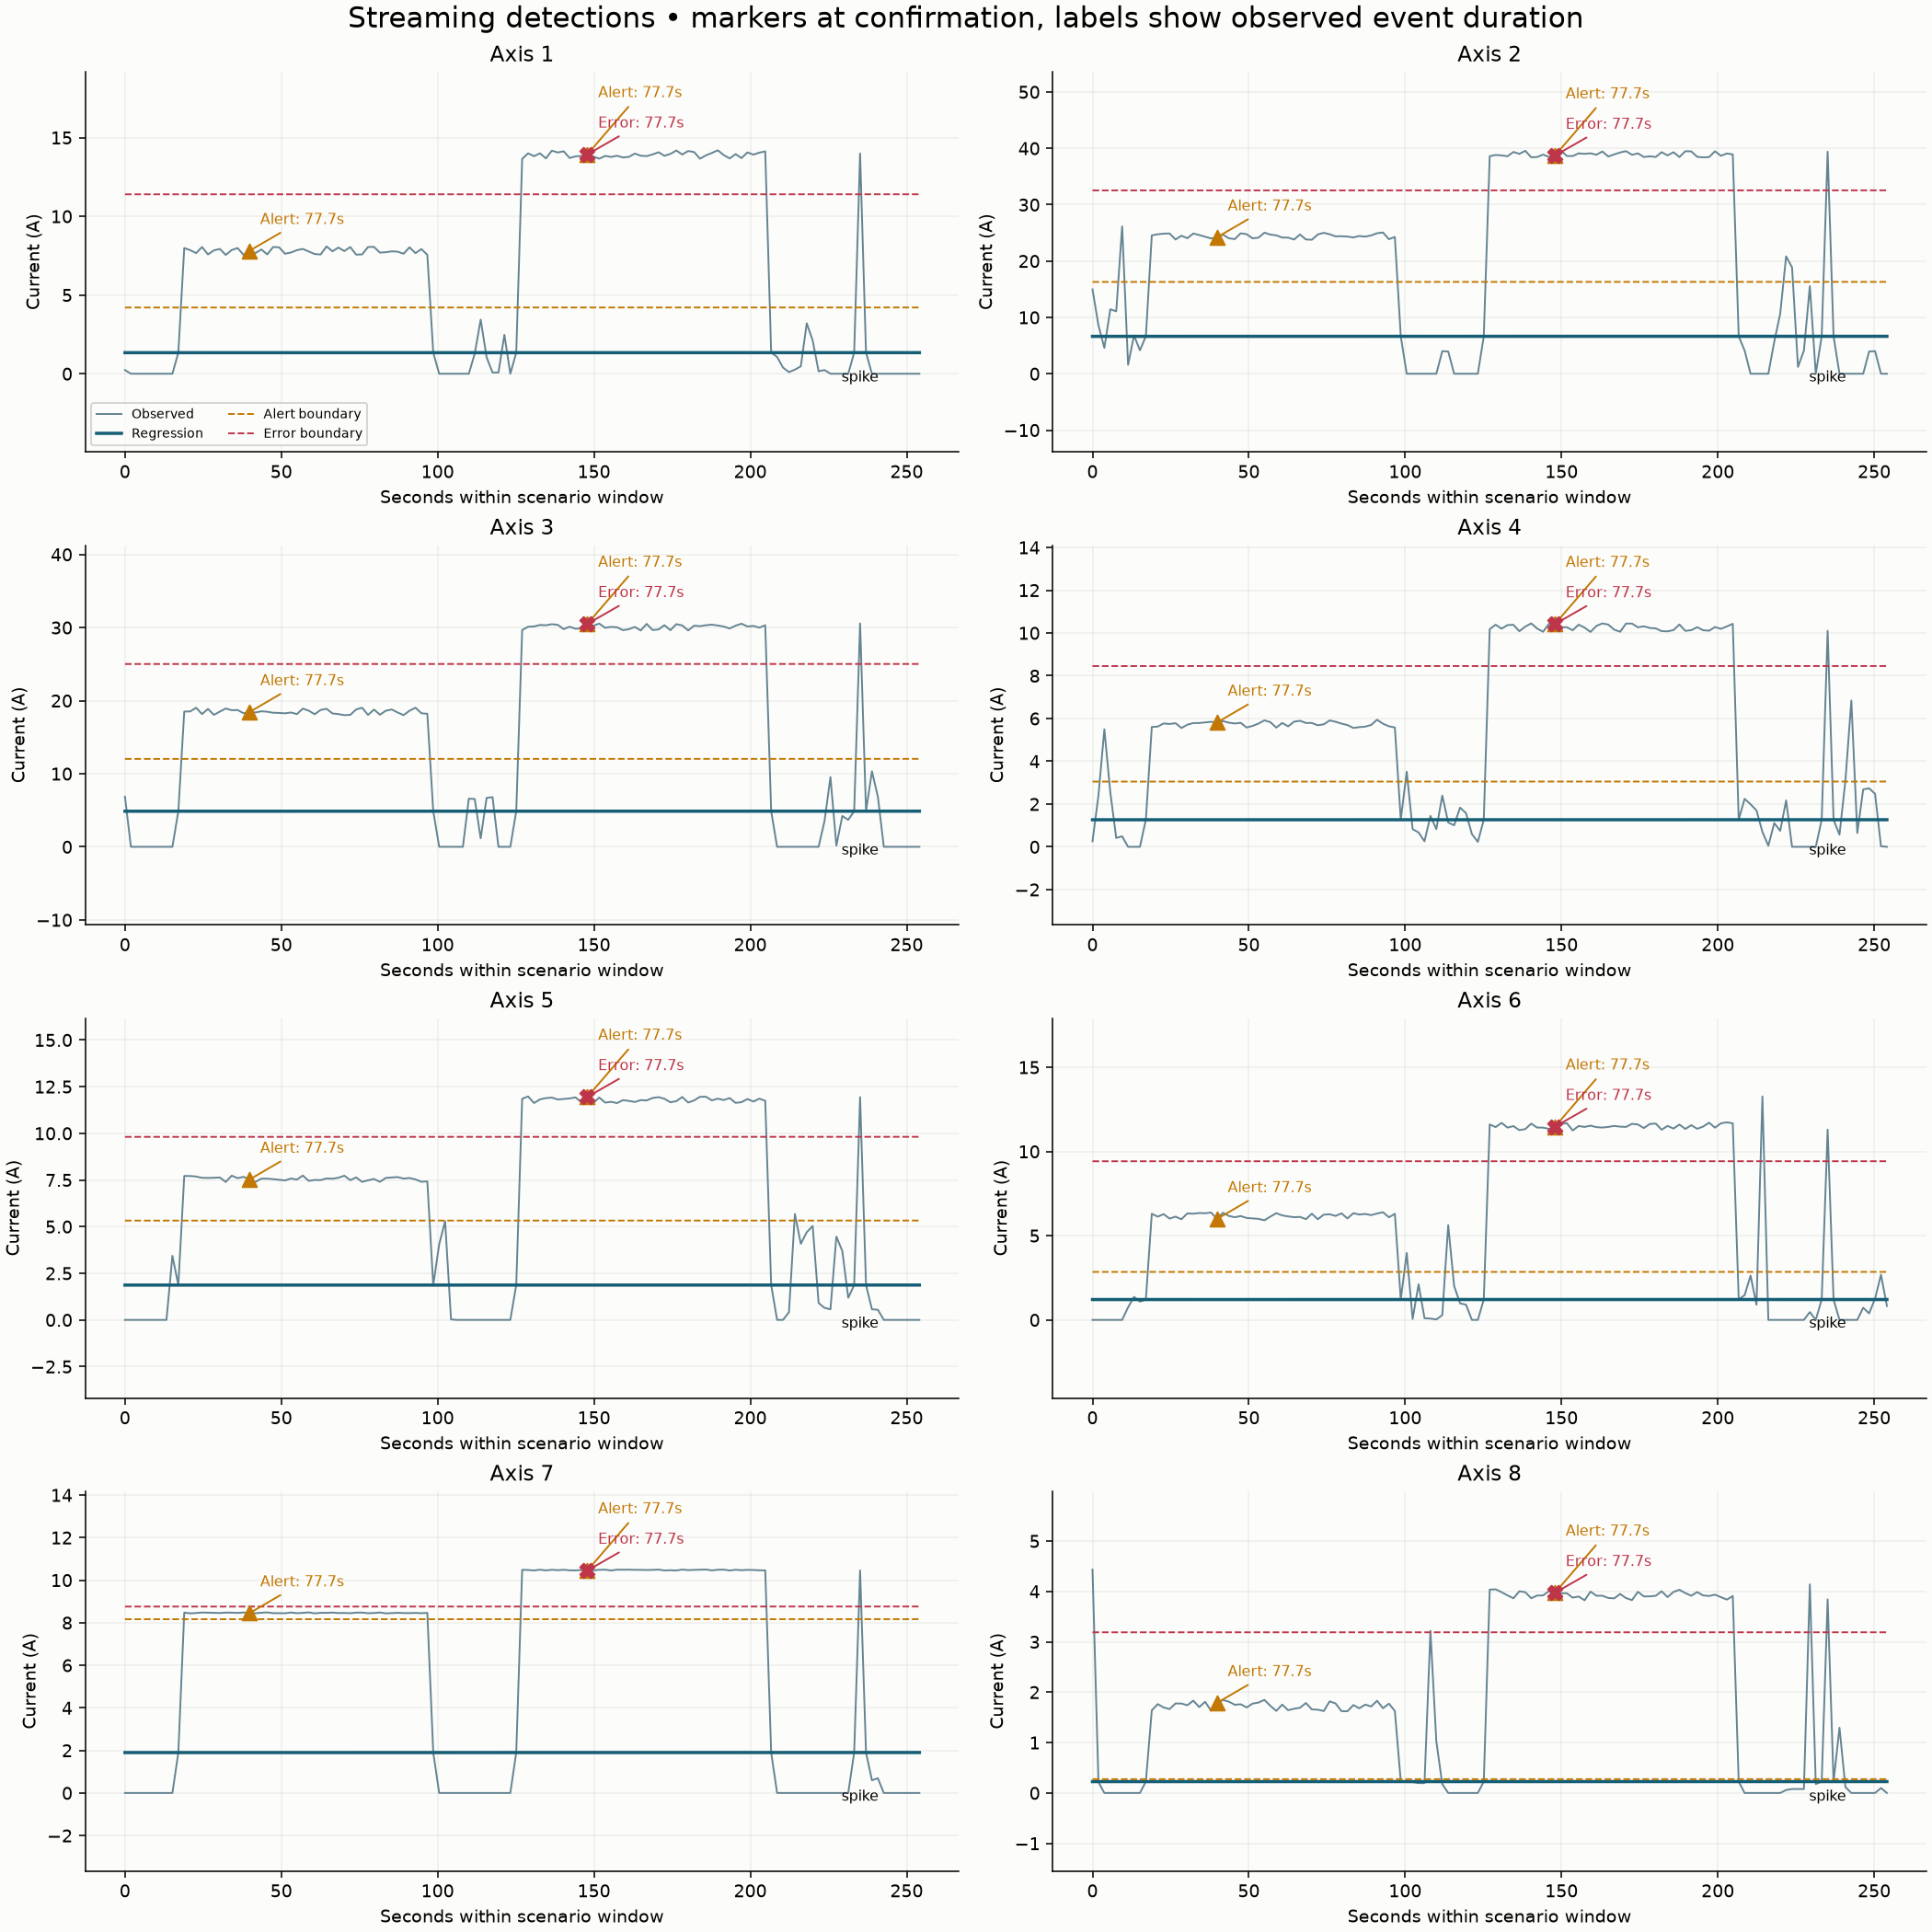

In [19]:
for name,frame in (("coefficients.csv",coefficients),("regression_metrics.csv",metrics),
    ("residual_diagnostics.csv",diagnostics),("thresholds.csv",thresholds),
    ("threshold_search_detail.csv",detail),("threshold_search.csv",grid),
    ("synthetic_moment_comparison.csv",moments),("normalization.csv",normalization),
    ("event_counts.csv",counts),("synthetic_evaluation.csv",evaluation),
    ("synthetic_threshold_sweep.csv",stress_sweep)):
    save_table(frame,root,name)
plot_events(stress,models,origin,thresholds,truth,event_frames['synthetic_stress'],plots/'alert_error_overlay.png')
display(Image(filename=str(plots/'alert_error_overlay.png'),width=1100))

#### 10. Reusing the original streaming pipeline

In [20]:
get_ipython().run_line_magic("matplotlib", "inline")
# REUSED VERBATIM: LiveDashboard and palette from the workshop.
# Validated 8-hue categorical palette, assigned to axes in fixed order.
# Never cycle or reorder these -- axis_3 must stay the same color when the
# chart is filtered or rescaled, or the reader has to re-learn it every tick.
AXIS_COLORS = {
    "axis_1": "#2a78d6",  # blue
    "axis_2": "#eb6834",  # orange
    "axis_3": "#1baf7a",  # aqua
    "axis_4": "#eda100",  # yellow
    "axis_5": "#e87ba4",  # magenta
    "axis_6": "#008300",  # green
    "axis_7": "#4a3aa7",  # violet
    "axis_8": "#e34948",  # red
}

SURFACE = "#fcfcfb"
INK = "#0b0b0b"
INK_MUTED = "#52514e"


class LiveDashboard:
    """Rolling per-axis current chart that redraws as readings arrive."""

    def __init__(self, window=30):
        self.window = window
        self.records = []

    def update(self, record):
        self.records.append(record)
        self.records = self.records[-self.window:]
        self.draw()

    def draw(self):
        df = pd.DataFrame(self.records)

        clear_output(wait=True)
        fig, ax = plt.subplots(figsize=(11, 4.5), facecolor=SURFACE)
        ax.set_facecolor(SURFACE)

        for column in AXIS_COLUMNS:
            ax.plot(
                df["reading_time"], df[column],
                color=AXIS_COLORS[column], linewidth=2,
                solid_capstyle="round", label=column.replace("axis_", "Axis "),
            )

        ax.set_title(
            f"Robot current by axis — last {len(df)} readings",
            color=INK, fontsize=13, fontweight="600", loc="left", pad=12,
        )
        ax.set_ylabel("current (A)", color=INK_MUTED, fontsize=10)
        ax.tick_params(colors=INK_MUTED, labelsize=9)

        # Recessive grid and axes: the data should be the darkest thing here.
        ax.grid(axis="y", color="#d8d7d2", linewidth=0.8, alpha=0.7)
        ax.set_axisbelow(True)
        for side in ("top", "right", "left"):
            ax.spines[side].set_visible(False)
        ax.spines["bottom"].set_color("#d8d7d2")

        # Legend outside the plot so it never covers the data.
        ax.legend(
            loc="center left", bbox_to_anchor=(1.01, 0.5),
            frameon=False, fontsize=9, labelcolor=INK_MUTED,
        )

        fig.autofmt_xdate()
        fig.tight_layout()
        display(fig)
        plt.close(fig)

        # Relief for the low-contrast hues: current values in text, not color alone.
        latest = df.iloc[-1]
        print("  ".join(f"{c.replace('axis_', 'A')}:{latest[c]:5.1f}" for c in AXIS_COLUMNS))


dashboard = LiveDashboard(window=30)
print("dashboard ready")


dashboard ready


#### Stream using the existing on_tick() pattern

The callback adds training-based scaling, test-table storage and regression checks.

We replay 240 rows around the first injected pattern. At speed 20, each 1.896-second synthetic interval becomes a requested 0.0948-second pause. Event timers still use robot timestamps. Each row is committed before the next row arrives.

init_stream_table() comes from the streaming_simulator.py. It creates the test table if needed and leaves historical readings untouched.

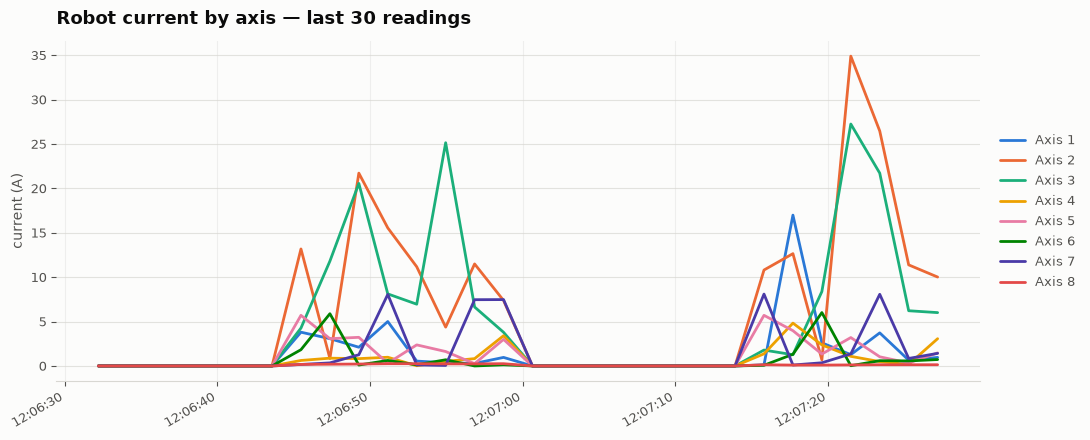

A1:  1.0  A2: 10.0  A3:  6.0  A4:  3.1  A5:  1.5  A6:  0.7  A7:  1.4  A8:  0.1


In [21]:
if cloud_demo:
    first = int(truth.start_index.min()) - 10
    run_id = uuid4()
    timings = []
    cloud_detector, prediction_tick, cloud_predictions = prediction_callback(
        models, origin, thresholds, cadence)

    ss = StreamingSimulator(root / "data/synthetic_stress.csv", interval=cadence["median_interval_s"] / replay_speed)
    ss.seek(first)

    with get_connection() as connection:
        init_stream_table(connection)
        connection.commit()
        started = time.monotonic()

        
        def on_tick(record):
            record["normalized_values"] = {
                axis: float(record[axis]) * scaling["axes"][axis]["minmax_scale"]
                      + scaling["axes"][axis]["minmax_offset"]
                for axis in AXES}
            record["standardized_values"] = {
                axis: (float(record[axis]) - scaling["axes"][axis]["mean_A"])
                      / scaling["axes"][axis]["zscore_scale_A"]
                for axis in AXES}

            
            insert_test_reading(record, run_id=run_id, sequence=len(timings), connection=connection)
            connection.commit()
            timings.append({"sequence": len(timings), "reading_time": record["reading_time"],
                            "elapsed_wall_seconds": time.monotonic() - started})
            prediction_tick(record)
            if dashboard is not None:
                dashboard.update(record)

        demo_records = ss.run(n_steps=240, on_tick=on_tick)
        wall_seconds = time.monotonic() - started

#### Query the saved readings and log the results

fetch_test_since() reuses _query() to retrieve only this run from the synthetic table. We compare every raw current and both scaled views with the CSV files. This confirms that the database saved the expected readings.
The timing CSV records requested pauses and actual arrival intervals. Separate CSVs store the notifications and completed events. An Error can also satisfy Alert, so two records can describe one incident.

In [22]:
if cloud_demo:
    # Query the separate test table using the added helper.
    sample = pd.DataFrame(demo_records)
    restored = fetch_test_since(sample.reading_time.min() - pd.Timedelta(seconds=1), run_id=run_id)
    assert len(restored) == len(sample)
    pd.testing.assert_frame_equal(
        restored[["trait", "reading_time", *AXES]].reset_index(drop=True),
        sample[["trait", "reading_time", *AXES]].reset_index(drop=True), check_dtype=False)
    for view in ("normalized", "standardized"):
        expected = pd.read_csv(root / f"data/synthetic_stress_{view}.csv").iloc[first:first+len(sample)]
        saved = pd.DataFrame(restored[f"{view}_values"].tolist())
        assert np.allclose(saved[AXES].to_numpy(), expected[RAW_AXES].to_numpy())

    audit = pd.DataFrame(timings)
    audit["event_interval_s"] = audit.reading_time.diff().dt.total_seconds()
    audit["requested_pause_s"] = audit.event_interval_s / replay_speed
    audit["observed_wall_interval_s"] = audit.elapsed_wall_seconds.diff()
    save_table(audit, root, "cloud_stream_timing.csv")
    cloud_events = cloud_detector.finish()
    save_table(cloud_events, root, "cloud_stream_events.csv")
    save_table(pd.DataFrame(cloud_detector.notifications), root, "cloud_stream_notifications.csv")
    save_table(pd.DataFrame(cloud_predictions), root, "cloud_stream_predictions.csv")
    cloud_report = {
        "run_id": str(run_id), "inserted_rows": len(sample), "queried_rows": len(restored),
        "table": "pm_lab_scaled_stream", "source_csv": "synthetic_stress.csv",
        "replay_speed": replay_speed, "wall_seconds": wall_seconds,
        "requested_pause_total_s": float(audit.requested_pause_s.sum()),
        "event_span_seconds": (sample.reading_time.max()-sample.reading_time.min()).total_seconds(),
        "scaling_training_source": source, "scaling_training_rows": len(fit),
        "raw_and_scaled_values_verified": True, "training_table_modified": False,
        "reused_functions": ["fetch_all", "get_connection", "_query", "StreamingSimulator.run", "LiveDashboard.update"],
        "original_dashboard_used": dashboard is not None}

    display(pd.Series(cloud_report, name="Workshop pipeline replay"))
    display(audit.head())
    display(cloud_events[["axis", "severity", "duration_s", "detection_delay_s"]])

run_id                                         7b1542ef-e103-413d-b654-f3d5e897161c
inserted_rows                                                                   240
queried_rows                                                                    240
table                                                          pm_lab_scaled_stream
source_csv                                                     synthetic_stress.csv
replay_speed                                                                   20.0
wall_seconds                                                               62.45738
requested_pause_total_s                                                     22.6572
event_span_seconds                                                          453.144
scaling_training_source                                                       cloud
scaling_training_rows                                                         23803
raw_and_scaled_values_verified                                              

,sequence,reading_time,elapsed_wall_seconds,event_interval_s,requested_pause_s,observed_wall_interval_s
0,0,2022-10-18 11:59:54.044000+00:00,0.09549,NaN,NaN,NaN
1,1,2022-10-18 11:59:55.940000+00:00,0.36948,1.896,0.0948,0.27399
2,2,2022-10-18 11:59:57.836000+00:00,0.62873,1.896,0.0948,0.25925
3,3,2022-10-18 11:59:59.732000+00:00,0.87999,1.896,0.0948,0.25126
4,4,2022-10-18 12:00:01.628000+00:00,1.16954,1.896,0.0948,0.28956


,axis,severity,duration_s,detection_delay_s
0,axis_1,Alert,77.736,20.856
1,axis_1,Alert,77.736,20.856
2,axis_1,Error,77.736,20.856


#### Reuse the interactive chart
 live_status already has helpers for rebuilding the data, keeping the last 90 seconds and plotting the eight currents. We use those helpers below. This current chart complements the new regression plots with annotated Alerts and Errors in section 9.
 
The unchanged web app still uses db.py to replay historical data. This notebook passes synthetic rows directly to its chart helpers; it does not change the web app to read the test table.

In [ ]:
if cloud_demo:
    chart_rows = live_status._from_records(live_status._to_records(restored))
    chart = live_status._build_figure(live_status._trim_to_window(chart_rows))
    chart.write_html(str(out/'workshop_current_chart.html'), include_plotlyjs=True)
    display(chart)
# Verify the existing dashboard layout can still be served, without starting a server.
from src.web_ui.web_ui_interface import app
assert app.server.test_client().get('/_dash-layout').status_code == 200
print('Original web dashboard layout loaded successfully.')

Original web dashboard layout loaded successfully.


#### Save the run details
The training source, database check, model coefficients and chosen rules are saved so that we can trace the results

In [24]:
metadata={"source":source,"executed_at_UTC":datetime.now(timezone.utc).isoformat(),
    "cloud_training_verified_against_csv":source=="cloud",
    "source_csv_sha256":hashlib.sha256((root/"data/RMBR4-2_export_test.csv").read_bytes()).hexdigest(),
    "rows":len(data),"fit_rows":len(fit),"calibration_rows":len(cal),"holdout_rows":len(holdout),
    "source_start_UTC":data.reading_time.min().isoformat(),"source_end_UTC":data.reading_time.max().isoformat(),
    "units":"A (amperes); kWh unavailable without electrical conversion inputs",
    "idle_fraction":float(data[AXES].eq(0).all(axis=1).mean()),
    "cadence":cadence,"synthetic":synthetic_meta,
    "origin_UTC":origin.isoformat(),"cloud_stream":None,
    "split_time_ranges":{name:[frame.reading_time.iloc[0].isoformat(),frame.reading_time.iloc[-1].isoformat()]
        for name,frame in (("fit",fit),("calibration",cal),("holdout",holdout))}}
if cloud_demo:
    metadata["cloud_stream"] = cloud_report
(out/"run_metadata.json").write_text(json.dumps(metadata,indent=2))
model_export={"origin_UTC":origin.isoformat(),"units":"A","coefficients":coefficients.to_dict("records"),
              "thresholds":thresholds.to_dict("records"),"max_gap_s":cadence["max_gap_s"]}
(out/"model_parameters.json").write_text(json.dumps(model_export,indent=2))
display(pd.Series({k:v for k,v in metadata.items() if k not in ('synthetic','split_time_ranges')},name='Run provenance'))

source                                                                             cloud
executed_at_UTC                                         2026-10-05T23:20:54.877253+00:00
cloud_training_verified_against_csv                                                 True
source_csv_sha256                      4bb00cf083629d9ec2d961fc9432723bc52b179c217a37...
rows                                                                               39672
fit_rows                                                                           23803
calibration_rows                                                                    7934
holdout_rows                                                                        7935
source_start_UTC                                        2022-10-17T12:18:23.660000+00:00
source_end_UTC                                          2022-10-18T10:44:58.628000+00:00
units                                  A (amperes); kWh unavailable without electrica...
idle_fraction        

#### 11.Summary & Findings

Here is what was done:
1. Read the robot’s past measurements.
   The lab loaded about 40,000 readings from the cloud database. Each reading showed the current used by the robot’s eight moving axes.
2. Learn a simple baseline.
   For each axis, the model fitted a straight line showing how current changed over time. This gave it an expected value to compare with new readings.
3. Choose when to raise a warning.
   A separate portion of historical data helped choose how far above the expected value the current could rise before being considered unusual. Each axis received different limits because their current levels differed.
4. Check whether the increase lasted.
   A moderate increase lasting at least 19 seconds triggered an Alert. A larger increase lasting that long triggered an Error. Brief spikes were ignored.
5. Test the system with simulated problems.
   The lab created test readings containing sustained increases and short spikes. It detected all 16 planned sustained increases and ignored all eight isolated spikes. It also saved and retrieved 240 test readings through Neon to check the streaming pipeline.
6. Show and save the findings.
   Charts showed where warnings occurred and how long the increases lasted. Event logs recorded the results for later review.
The main finding was that the warning system worked as designed, but the simple model did not predict normal current very well. Robot activity changed too much to be explained by time alone.
An Alert or Error therefore means “check what is happening”, not “the robot is definitely failing.” Higher current might result from a heavier workload or a different task. Likewise, no warning does not guarantee that everything is healthy.
The lab demonstrated a useful monitoring approach. Predicting real failures would require more operating data, information about workload and robot activity, and examples of confirmed faults.